## Imports and Loading Data 

In [1]:
# IMPORT LIBRARIES
import os # file path operations
import pandas as pd # data loading/manipulation
import numpy as np # numerical operations
import matplotlib.pyplot as plt # base plotting
import seaborn as sns # statistical charts
import numpy as np
import plotly.express as px

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier # gradient-boosted trees baseline model
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import recall_score, precision_score, precision_recall_curve
from sklearn.metrics import roc_auc_score, average_precision_score

print("✅ SUCCESS: All libraries imported")

✅ SUCCESS: All libraries imported


In [2]:
# LOADING RAW DATASETS
# Raw data files untouched, cleaning occurs on copies

# [EDIT AS NEEDED] Path to data folder
DATASET_PATH = "../data/raw"


# Name files
svi_file = "SVI_2022_US_county.csv"
places_file = "PLACES__Local_Data_for_Better_Health,_County_Data,_2025_release_20260725.csv"
nchs_file = "NCHSurb-rural-codes.csv"

# Load data

# SVI 2022 - 3144 rows (/county), 158 cols
df_svi_raw = pd.read_csv(f"{DATASET_PATH}/{svi_file}")

# PLACES 2025 - ~240k rows (/county x health measure)
df_places_raw = pd.read_csv(f"{DATASET_PATH}/{places_file}",
                              low_memory=False) # account for file size

# NCHS: one row/county with 1-6 NCHS code
df_nchs_raw = pd.read_csv(f"{DATASET_PATH}/{nchs_file}",
                            encoding="latin-1") # acc for special characters

print ("✅ SUCCESS: All data sets loaded.")
print(f"SVI:    {df_svi_raw.shape[0]} counties, {df_svi_raw.shape[1]} columns")
print(f"PLACES: {df_places_raw.shape[0]} rows, {df_places_raw.shape[1]} columns")
print(f"NCHS:   {df_nchs_raw.shape[0]} rows, {df_nchs_raw.shape[1]} columns")



✅ SUCCESS: All data sets loaded.
SVI:    3144 counties, 158 columns
PLACES: 229298 rows, 22 columns
NCHS:   3160 rows, 11 columns


## Data Analysis (Raw Data)

In [3]:
# ANALYZING RAW DATA - run once to visualize before cleaning
# Key factors:
# Column titles (selecting features/joining datasets)
# -999 SVI values = missing/unavail census data; not used after
# RPL scores range 0-1 | EP_ cols range 0-100
# PLACES MeasureID strings (filter measures)
# NCHS rural code col name/scale (1-6)

print("------------- SVI: column titles first 5 rows -------------")
print(df_svi_raw.columns.tolist())
print(df_svi_raw.head(5))

print("\n------------- SVI: RPL column stats -------------")
rpl_cols = [c for c in df_svi_raw.columns if c.startswith("RPL_")]
print(df_svi_raw[rpl_cols].describe().round(3)) # look for -999 as min

print("\n------------- SVI: # missing values (top 10 columns) -------------")
print(df_svi_raw.isna().sum().sort_values(ascending=False).head(10))

print("\n------------- PLACES: column titles and first 5 rows -------------")
print(df_places_raw.columns.tolist())
print(df_places_raw.head(5))

print("\n------------- PLACES: unique MeasureIDS -------------") # find strings here
print(sorted(df_places_raw["MeasureId"].unique()))

print("\n------------- NCHS: column titles and first 5 rows -------------")
print(df_nchs_raw.columns.tolist())
print(df_nchs_raw.head(5))

print("\n------------- FIPS FORMAT CHECK -------------")
print("SVI FIPS: ", df_svi_raw["FIPS"].head(3).tolist())
print("PLACES FIPS: ", df_places_raw["LocationID"].head(3).tolist())

------------- SVI: column titles first 5 rows -------------
['ST', 'STATE', 'ST_ABBR', 'STCNTY', 'COUNTY', 'FIPS', 'LOCATION', 'AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP', 'E_HU', 'M_HU', 'E_HH', 'M_HH', 'E_POV150', 'M_POV150', 'E_UNEMP', 'M_UNEMP', 'E_HBURD', 'M_HBURD', 'E_NOHSDP', 'M_NOHSDP', 'E_UNINSUR', 'M_UNINSUR', 'E_AGE65', 'M_AGE65', 'E_AGE17', 'M_AGE17', 'E_DISABL', 'M_DISABL', 'E_SNGPNT', 'M_SNGPNT', 'E_LIMENG', 'M_LIMENG', 'E_MINRTY', 'M_MINRTY', 'E_MUNIT', 'M_MUNIT', 'E_MOBILE', 'M_MOBILE', 'E_CROWD', 'M_CROWD', 'E_NOVEH', 'M_NOVEH', 'E_GROUPQ', 'M_GROUPQ', 'EP_POV150', 'MP_POV150', 'EP_UNEMP', 'MP_UNEMP', 'EP_HBURD', 'MP_HBURD', 'EP_NOHSDP', 'MP_NOHSDP', 'EP_UNINSUR', 'MP_UNINSUR', 'EP_AGE65', 'MP_AGE65', 'EP_AGE17', 'MP_AGE17', 'EP_DISABL', 'MP_DISABL', 'EP_SNGPNT', 'MP_SNGPNT', 'EP_LIMENG', 'MP_LIMENG', 'EP_MINRTY', 'MP_MINRTY', 'EP_MUNIT', 'MP_MUNIT', 'EP_MOBILE', 'MP_MOBILE', 'EP_CROWD', 'MP_CROWD', 'EP_NOVEH', 'MP_NOVEH', 'EP_GROUPQ', 'MP_GROUPQ', 'EPL_POV150', 'EPL_UNEMP', '

## Clean and Merge Datasets

In [4]:
# STANDARDIZING FIPS CODES FOR UNIFORMITY ACROSS ALL DATASETS
# FIPS = 5-digit county identifier
# Ensure all 3 FIPS dataset values identical for merge
# str.zfill adds leading zeros

df_svi_raw["FIPS"] = df_svi_raw["FIPS"].astype(str).str.zfill(5)
df_places_raw["FIPS"] = df_places_raw["LocationID"].astype(str).str.zfill(5)

# NCHS = no single FIPS column, combine STFIPS (state) + CTYFIPS (county)

df_nchs_raw["FIPS"] = (
    df_nchs_raw["STFIPS"].astype(str).str.zfill(2) +
    df_nchs_raw["CTYFIPS"].astype(str).str.zfill(3)
)

print("FIPS after standardization: ensure formatted with 5 digits ['01001',...]")
print("SVI: ", df_svi_raw["FIPS"].head(3).tolist())
print("PLACES: ", df_places_raw["FIPS"].head(3).tolist())
print("NCHS: ", df_nchs_raw["FIPS"].head(3).tolist())

FIPS after standardization: ensure formatted with 5 digits ['01001',...]
SVI:  ['01001', '01003', '01005']
PLACES:  ['05043', '05049', '05061']
NCHS:  ['01001', '01003', '01005']


In [5]:
# CLEAN SVI

svi = df_svi_raw.copy() # make copy to clean

# 1. Replace -999 values with NaN
svi = svi.replace(-999, np.nan)
print("Min RPL_THEMES after -999 replacement, if any (0.0 or NaN, not -999):")
print(svi["RPL_THEMES"].min())

# 2. Select evidence-based columns from literature findings in Silva et al. 2024
# /Ramphul et al. 2025
# EP_ = Estimate Percentage (raw %)
# RPL_ = Rank Percentile (0-1 scale, national ranking)

svi_cols = [
    # Identifiers for merging/labeling results
    "FIPS", "COUNTY", "ST_ABBR",

    # Overall SVI and four theme composites
    # RPL_THEMES = overall vulnerability - label engineering (Signal 1)
    # RPL_THEME4 = housing/transportation

    "RPL_THEMES","RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4",

    # Individual features linked to literature findings
    "EP_NOVEH",   # % no vehicle - strongest individual SVI predictor
    "EP_AFAM",    # % Black/African American (OR = 1.69)
    "EP_UNINSUR", # % uninsured (OR = 1.90) (Medicaid/charity vs. private)
    "EP_LIMENG",  # % limited English (OR = 1.34)
    "EP_POV150",  # % below 150% poverty — both papers
    "EP_UNEMP",   # % unemployed — Silva
    "EP_NOHSDP",  # % no high school diploma — SES composite component
    "EP_HISP",    # % Hispanic/Latino — both papers
    "EP_MUNIT",   # % multiunit housing — housing instability proxy
    "EP_HBURD",   # % housing cost burden — Silva
    "EP_DISABL",  # % disability — household composition subscore
    "EP_MINRTY"   # % minority overall — composite minority measure
]

# Account for column title variations across annual SVI datasets
svi_cols = [c for c in svi_cols if c in svi.columns]
svi = svi[svi_cols].copy()

# Summary
print(f"\nSVI cleaned: {svi.shape[0]} counties, {svi.shape[1]} columns")
print("Remaining missing values:")
print(svi.isna().sum()[svi.isna().sum() > 0])

Min RPL_THEMES after -999 replacement, if any (0.0 or NaN, not -999):
0.0

SVI cleaned: 3144 counties, 20 columns
Remaining missing values:
Series([], dtype: int64)


In [6]:
# CLEAN PLACES

# Select evidence-based PLACES measures
places_measures = {
    "MAMMOUSE": "MAMMOGRAPHY",       # OB/GYN preventative care proxy replacing
                                     # CERVICAL, unavailable in PLACES 2025
    "CHECKUP": "ANNUAL_CHECKUP",     # healthcare system access proxy - Silva
    "OBESITY": "OBESITY_PREV",       # PMOS comorbidity - Silva, Ramphul, Neven
    "DIABETES": "DIABETES_PREV",     # PMOS comorbidity - Silva, Neven
    "DEPRESSION": "DEPRESSION_PREV", # PMOS psychosocial comorbidity - Neven
    "HIGHCHOL": "HIGH_CHOL_PREV",    # PMOS psychosocial comorbidity - Neven, Ramphul
                                     # 2% missing values, kept in
    "FOODINSECU": "FOOD_INSECURITY", # 23% missing values, SES/food access proxy — Ramphul
}

# 1. Filter rows to 7 evidence-based health measures
places_filtered = df_places_raw[
    (df_places_raw["MeasureId"].isin(places_measures.keys())) &
    (df_places_raw["Data_Value_Type"] == "Age-adjusted prevalence")
    ][["FIPS","MeasureId","Data_Value"]]

print("Rows found per measure (0 = wrong MeasureId string given in measures above):")
print(places_filtered["MeasureId"].value_counts())

# 2. Change from long (one row per county x measure)
# to wide format (one row per county, one col per measure)
places = places_filtered.pivot_table(
    index="FIPS",
    columns="MeasureId",
    values="Data_Value"
).reset_index()

# Rename cols to readable titles
places = places.rename(columns=places_measures)

# Summary
print(f"\nPLACES pivoted: {places.shape[0]} counties, {places.shape[1]} columns")
print("Remaining missing values (NaN):")
print(places.isna().sum())

Rows found per measure (0 = wrong MeasureId string given in measures above):
MeasureId
MAMMOUSE      3145
OBESITY       2958
DEPRESSION    2958
HIGHCHOL      2958
CHECKUP       2958
DIABETES      2958
FOODINSECU    2300
Name: count, dtype: int64

PLACES pivoted: 3144 counties, 8 columns
Remaining missing values (NaN):
MeasureId
FIPS                 0
ANNUAL_CHECKUP     187
DEPRESSION_PREV    187
DIABETES_PREV      187
FOOD_INSECURITY    844
HIGH_CHOL_PREV     187
MAMMOGRAPHY          0
OBESITY_PREV       187
dtype: int64


In [7]:
# CLEAN NCHS CODES
# Scale: 1 = large metro area | 6 = rural area (higher = inc rural)
# Select only FIPS and 2023 urban-rural code

nchs = df_nchs_raw[["FIPS","CODE2023"]].rename(
    columns={"CODE2023": "RURAL_CODE"}
).copy()

# Summary
print("Rural code distribution(1=most urban, 6=most rural):")
print(nchs["RURAL_CODE"].value_counts().sort_index())
print(f"Total # Codes: {nchs["RURAL_CODE"].count()}") # Ensure 3,144

Rural code distribution(1=most urban, 6=most rural):
RURAL_CODE
1.0      67
2.0     368
3.0     395
4.0     356
5.0     658
6.0    1300
Name: count, dtype: int64
Total # Codes: 3144


In [8]:
# MERGE ALL THREE DATASETS
# SVI (3,144 counties) as base
# PLACES and NCHS data matched by FIPS

df = svi.merge(places, on="FIPS", how="left")
df = df.merge(nchs, on="FIPS", how="left")

print(f"Merged shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Features included: {df.columns.tolist()}")

# Check for too few rows = FIPS mismatch betw datasets
# -> FIPS standardization issue
if df.shape[0] != 3144:
  print("⚠️ WARNING: merged file contains fewer counties than expected")
  print("SVI unique FIPS: ", svi["FIPS"].nunique())
  print("PLACES unique FIPS: ", places["FIPS"].nunique())
  print("NCHS unique FIPS: ", nchs["FIPS"].nunique())
else:
  print("✅ SUCCESS: all 3,144 counties and 25 features counted")

print("\nMissing values after merge:")
print(df.isna().sum()[df.isna().sum() > 0])


Merged shape: 3144 rows, 28 columns
Features included: ['FIPS', 'COUNTY', 'ST_ABBR', 'RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4', 'EP_NOVEH', 'EP_AFAM', 'EP_UNINSUR', 'EP_LIMENG', 'EP_POV150', 'EP_UNEMP', 'EP_NOHSDP', 'EP_HISP', 'EP_MUNIT', 'EP_HBURD', 'EP_DISABL', 'EP_MINRTY', 'ANNUAL_CHECKUP', 'DEPRESSION_PREV', 'DIABETES_PREV', 'FOOD_INSECURITY', 'HIGH_CHOL_PREV', 'MAMMOGRAPHY', 'OBESITY_PREV', 'RURAL_CODE']
✅ SUCCESS: all 3,144 counties and 25 features counted

Missing values after merge:
ANNUAL_CHECKUP     188
DEPRESSION_PREV    188
DIABETES_PREV      188
FOOD_INSECURITY    845
HIGH_CHOL_PREV     188
MAMMOGRAPHY          1
OBESITY_PREV       188
dtype: int64


In [9]:
# INVESTIGATING 188 MISSING PLACES VALUES
# MAMMOUSE has 6,290 rows in PLACES 2025 but other measures have 5,916
# After pivot: ~188 counties missing per measure — identify which and why

missing_counties = places[places["ANNUAL_CHECKUP"].isna()][["FIPS"]].copy()
missing_counties = missing_counties.merge(
    df[["FIPS", "COUNTY", "ST_ABBR", "RURAL_CODE", "EP_POV150"]],
    on="FIPS", how="left"
)

print(f"Counties missing PLACES measures (excl. MAMMOGRAPHY): {len(missing_counties)}")

# Check rural distribution — small/rural counties more likely suppressed by CDC
print("\nRural code distribution of missing counties (1=urban, 6=rural):")
print(missing_counties["RURAL_CODE"].value_counts().sort_index())

# Check state distribution — concentrated in specific states?
print("\nTop 10 states with missing counties:")
print(missing_counties["ST_ABBR"].value_counts().head(10))

# Compare poverty rate — are missing counties systematically poorer?
print(f"\nMean poverty rate (EP_POV150):")
print(f"  Missing counties: {missing_counties['EP_POV150'].mean():.2f}%")
print(f"  All counties:     {df['EP_POV150'].mean():.2f}%")

Counties missing PLACES measures (excl. MAMMOGRAPHY): 187

Rural code distribution of missing counties (1=urban, 6=rural):
RURAL_CODE
1.0     3
2.0    25
3.0    25
4.0    19
5.0    49
6.0    66
Name: count, dtype: int64

Top 10 states with missing counties:
ST_ABBR
KY    120
PA     67
Name: count, dtype: int64

Mean poverty rate (EP_POV150):
  Missing counties: 26.49%
  All counties:     23.95%


In [10]:
# ADDING CENSUS REGION AS A GEOGRAPHIC FEATURE
# RURAL_CODE is excluded in model training due to use as Signal 3 in label
# Region is different geographic feature - carries different signal than NCHS
# codes, supported by Visualization 3 (Southern/gulf states = higher SVI)

# State abbrievation: official US Census Bureau region
region_map = {
    'CT':'Northeast','ME':'Northeast','MA':'Northeast','NH':'Northeast',
    'RI':'Northeast','VT':'Northeast','NJ':'Northeast','NY':'Northeast',
    'PA':'Northeast',
    'IL':'Midwest','IN':'Midwest','MI':'Midwest','OH':'Midwest','WI':'Midwest',
    'IA':'Midwest','KS':'Midwest','MN':'Midwest','MO':'Midwest','NE':'Midwest',
    'ND':'Midwest','SD':'Midwest',
    'DE':'South','FL':'South','GA':'South','MD':'South','NC':'South',
    'SC':'South','VA':'South','DC':'South','WV':'South','AL':'South',
    'KY':'South','MS':'South','TN':'South','AR':'South','LA':'South',
    'OK':'South','TX':'South',
    'AZ':'West','CO':'West','ID':'West','MT':'West','NV':'West','NM':'West',
    'UT':'West','WY':'West','AK':'West','CA':'West','HI':'West','OR':'West',
    'WA':'West'
}

df['REGION'] = df['ST_ABBR'].map(region_map)

# Error check for missing states - should be empty
print("Unmapped states (should be empty):", df[df['REGION'].isna()]
 ['ST_ABBR'].unique())
# Ensure all regions filled
print("\nCounties per region:")
print(df['REGION'].value_counts())

# Encoding step, converts to int 0-1, creates one new col/val
# Drop first region alphabetically to prevent multicollinearity
df = pd.get_dummies(df, columns=['REGION'], drop_first=True, dtype=int)

# Midwest (first region, baseline (0,0,0)) should be dropped
print("\nNew columns added:",
 [c for c in df.columns if c.startswith('REGION_')])


Unmapped states (should be empty): <ArrowStringArray>
[]
Length: 0, dtype: str

Counties per region:
REGION
South        1422
Midwest      1055
West          449
Northeast     218
Name: count, dtype: int64

New columns added: ['REGION_Northeast', 'REGION_South', 'REGION_West']


In [11]:
# PRE-IMPUTATION BIAS CHECK
# Before filling missing values, check whether missing counties differ
# systematically from complete counties on key demographic indicators
# Systematic differences = imputation may introduce bias

# Columns with missing values (from merge output)
missing_cols = [c for c in df.columns if df[c].isna().any()]
print(f"Columns with missing values: {missing_cols}\n")

# For each missing column, compare key demographics of missing vs complete counties
check_cols = ["EP_POV150", "EP_AFAM", "EP_MINRTY", "RURAL_CODE"]

rows = []
for col in missing_cols:
    missing_mask = df[col].isna()
    for demo in check_cols:
        rows.append({
            "Missing Column": col,
            "Demographic":    demo,
            "Missing Mean":   df.loc[missing_mask,  demo].mean(),
            "Complete Mean":  df.loc[~missing_mask, demo].mean(),
            "N Missing":      missing_mask.sum(),
        })

bias_check = pd.DataFrame(rows).round(3)
print("Mean demographic values: missing vs complete counties")
print(bias_check.to_string(index=False))

Columns with missing values: ['ANNUAL_CHECKUP', 'DEPRESSION_PREV', 'DIABETES_PREV', 'FOOD_INSECURITY', 'HIGH_CHOL_PREV', 'MAMMOGRAPHY', 'OBESITY_PREV']

Mean demographic values: missing vs complete counties
 Missing Column Demographic  Missing Mean  Complete Mean  N Missing
 ANNUAL_CHECKUP   EP_POV150        26.391         23.800        188
 ANNUAL_CHECKUP     EP_AFAM         3.716          9.052        188
 ANNUAL_CHECKUP   EP_MINRTY        10.914         26.204        188
 ANNUAL_CHECKUP  RURAL_CODE         4.527          4.618        188
DEPRESSION_PREV   EP_POV150        26.391         23.800        188
DEPRESSION_PREV     EP_AFAM         3.716          9.052        188
DEPRESSION_PREV   EP_MINRTY        10.914         26.204        188
DEPRESSION_PREV  RURAL_CODE         4.527          4.618        188
  DIABETES_PREV   EP_POV150        26.391         23.800        188
  DIABETES_PREV     EP_AFAM         3.716          9.052        188
  DIABETES_PREV   EP_MINRTY        10.914    

In [12]:
# HANDLE MISSING VALUES

# Check for missing values
missing_pct = df.isna().mean().sort_values(ascending=False)
print("Missing value rates (columns with any missing values):")
print(missing_pct[missing_pct > 0].round(3))

# 1. Drop columns with > 30% missing, but check validate with literature
high_missing = missing_pct[missing_pct > 0.30].index.tolist()
if high_missing:
  print(f"\nDropping {len(high_missing)} high missing values column(s): {high_missing}")
  print(f"\n‼️ Please validate dropped columns to ensure proper exclusion")
  df = df.drop(columns=high_missing)
else:
  print("\nAll columns kept. No columns exceed 30% missing values.")

# 2. Fill missing values w/ column median to account for outliers
num_cols = df.select_dtypes(include=[np.number]).columns
filled_cols = [col for col in num_cols if df[col].isna().any()]
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

remaining = df.isna().sum().sum()
print(f"\nMissing values remaining: {remaining}")
if remaining == 0:
  print("✅ SUCCESS: Missing values cleaned from merged dataset.")
  print(f"Columns filled with medians: {filled_cols}")
else:
  print(f"⚠️ WARNING: {remaining} missing values still exist.")



Missing value rates (columns with any missing values):
FOOD_INSECURITY    0.269
OBESITY_PREV       0.060
HIGH_CHOL_PREV     0.060
DIABETES_PREV      0.060
DEPRESSION_PREV    0.060
ANNUAL_CHECKUP     0.060
MAMMOGRAPHY        0.000
dtype: float64

All columns kept. No columns exceed 30% missing values.

Missing values remaining: 0
✅ SUCCESS: Missing values cleaned from merged dataset.
Columns filled with medians: ['ANNUAL_CHECKUP', 'DEPRESSION_PREV', 'DIABETES_PREV', 'FOOD_INSECURITY', 'HIGH_CHOL_PREV', 'MAMMOGRAPHY', 'OBESITY_PREV']


## Dataset Visualizations

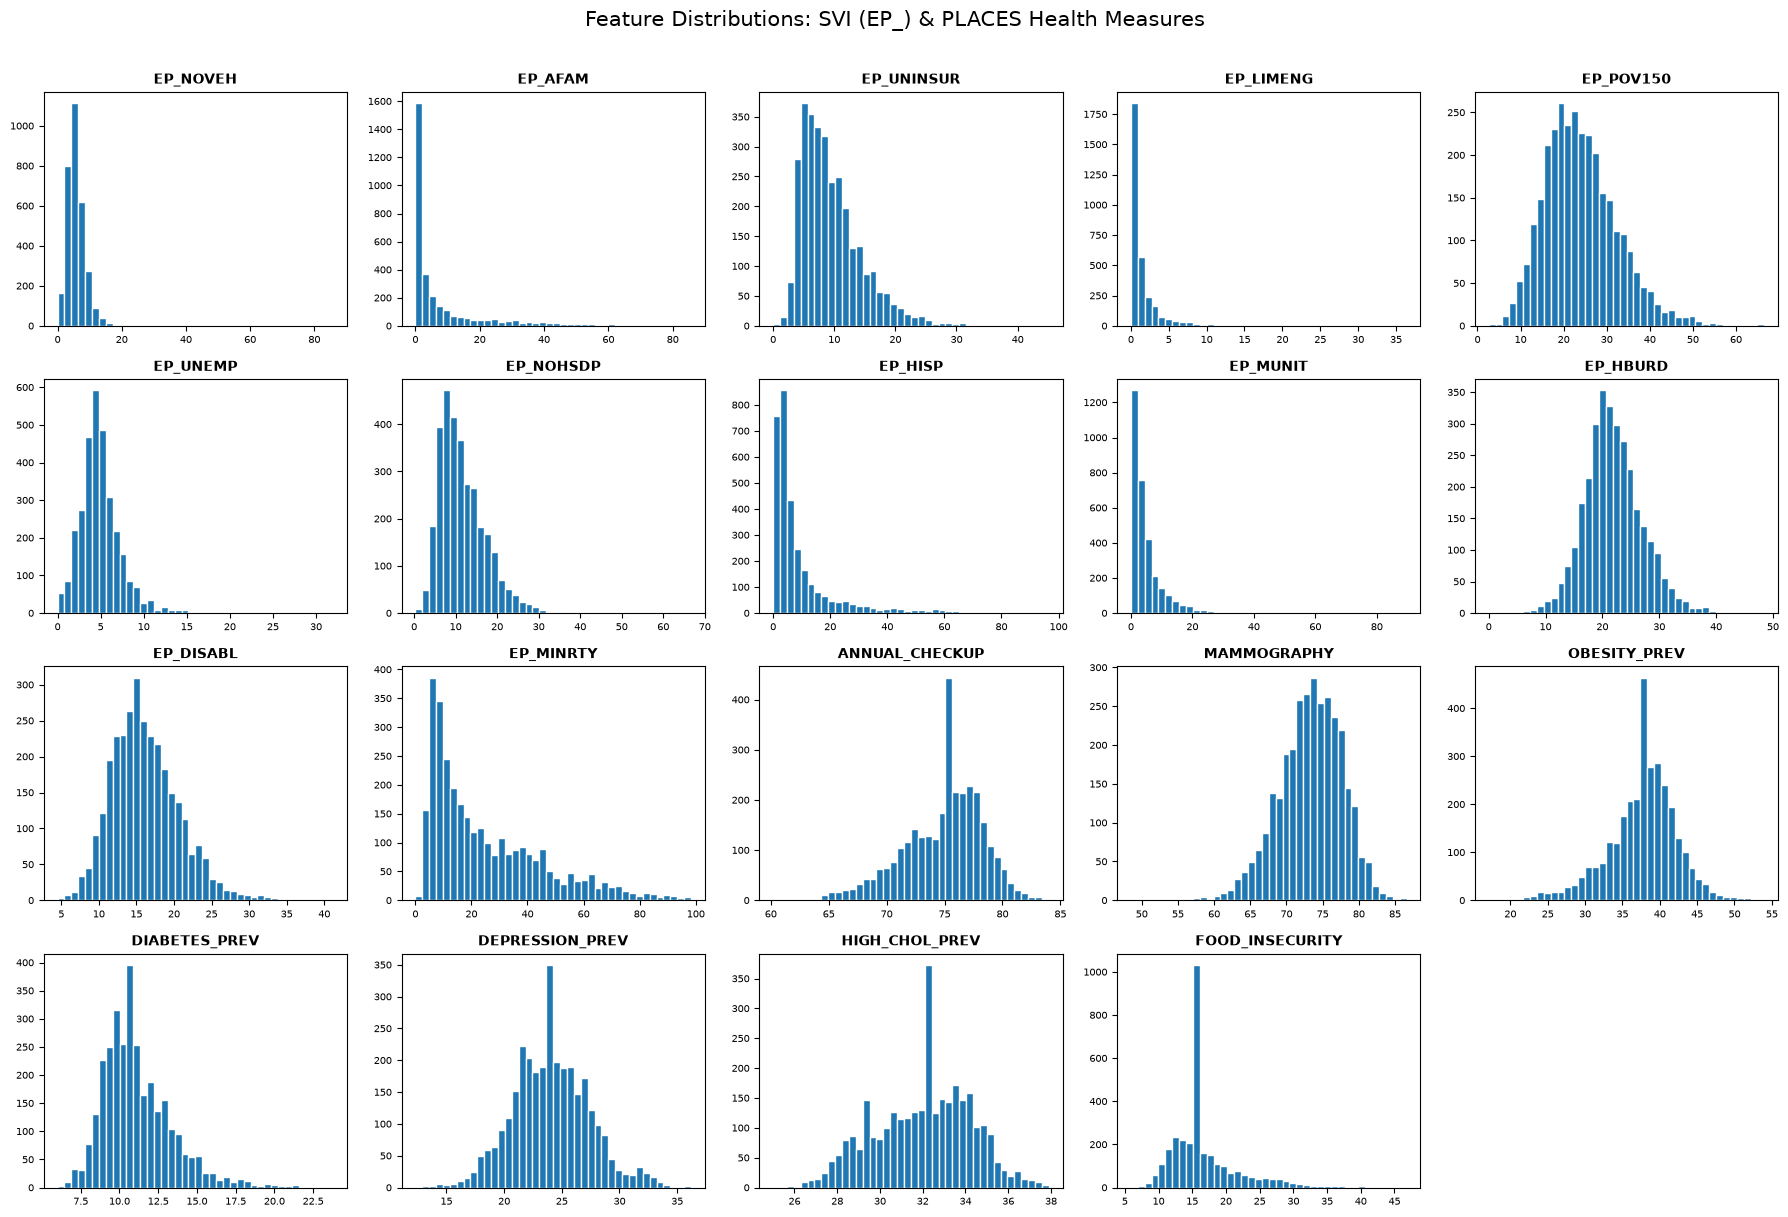

In [13]:
# Visualization 1: Feature Distributions
svi_cols  = [c for c in df.columns if c.startswith("EP_")]

places_cols = ["ANNUAL_CHECKUP", "MAMMOGRAPHY", "OBESITY_PREV",
            "DIABETES_PREV", "DEPRESSION_PREV", "HIGH_CHOL_PREV",
               "FOOD_INSECURITY"]

plot_cols = svi_cols + places_cols   # 19 total

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col].dropna(), bins=40, edgecolor="white")
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].tick_params(labelsize=7)

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions: SVI (EP_) & PLACES Health Measures",
             fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

**Key Observations for Visualization 1:**
- Most SVI features like `EP_AFAM`, `EP_LIMENG`, and `EP_MUNIT`are right-skewed. That means the majority of counties have low values with a long tail of high-vulnerability outliers.  
- PLACES health measures like `MAMMOGRAPHY`, `ANNUAL_CHECKUP`, and `OBESITY_PREV` are normally distributed, meaning these outcomes vary more evenly across counties
- `MAMMOGRAPHY` is approximately normally distributed. The remaining PLACES health measures (`ANNUAL_CHECKUP`, `OBESITY_PREV`, `DIABETES_PREV`, `DEPRESSION_PREV`, `HIGH_COL_PREV`) show a visible spike at their median value, caused by median imputation applied to the **188** Kentucky and Pennsylvania counties missing from PLACES 2025.
- `FOOD_INSECURITY` stands out with the sharpest spike near its median due a larger imputation of **844** counties.

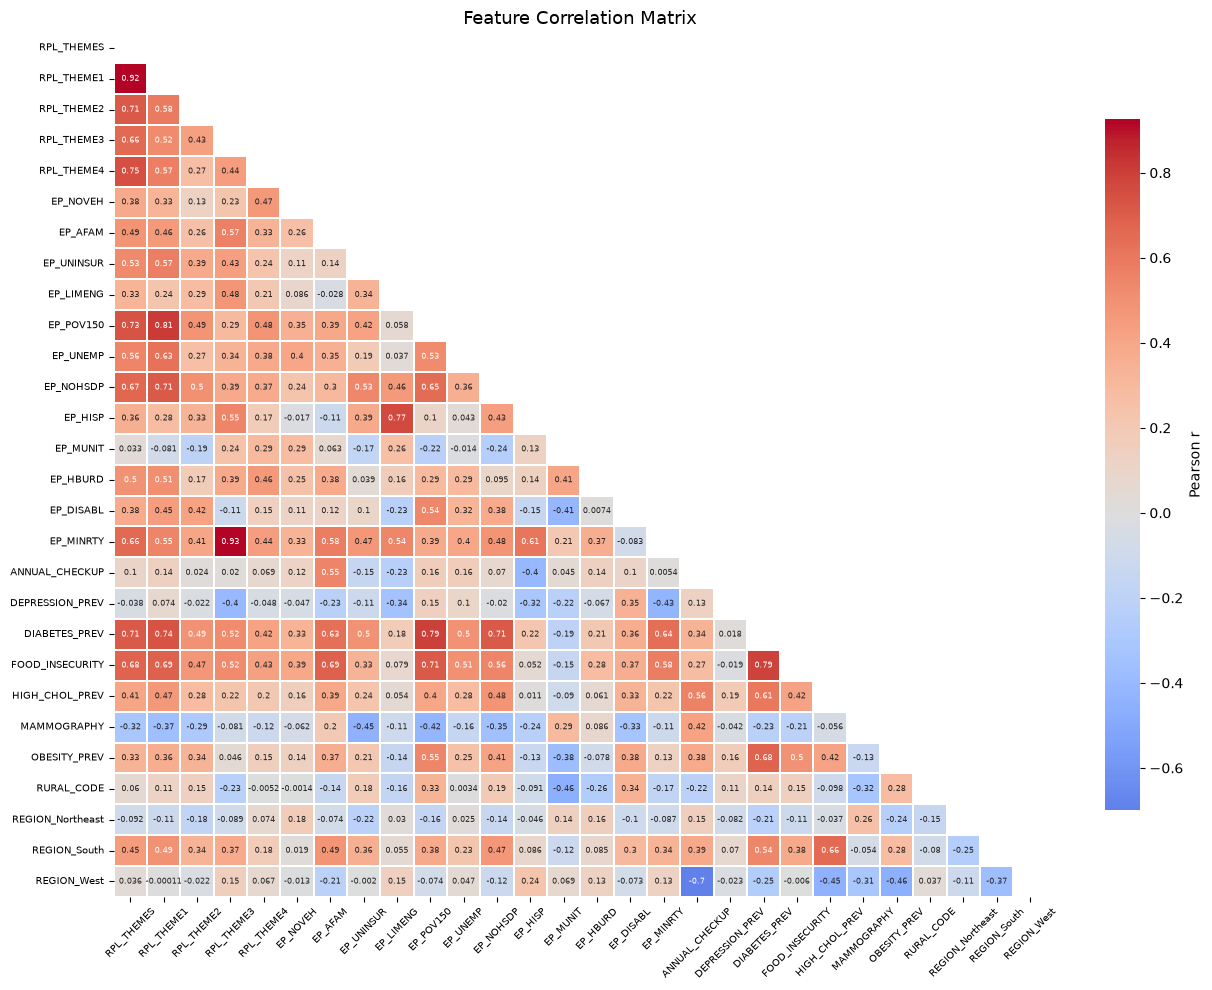

Highly correlated pairs (|r| > 0.75): 6
      Feature_A     Feature_B        r
      EP_MINRTY    RPL_THEME3 0.926847
     RPL_THEME1    RPL_THEMES 0.921377
      EP_POV150    RPL_THEME1 0.808009
  DIABETES_PREV     EP_POV150 0.794573
FOOD_INSECURITY DIABETES_PREV 0.791787
        EP_HISP     EP_LIMENG 0.770456


In [14]:
# Visualization 2: Correlation Heatmap

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr     = df[num_cols].corr() # Pearson correlation coefficient

fig, ax  = plt.subplots(figsize=(13, 10))
mask     = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle

sns.heatmap(
    data=corr,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    annot_kws={"size": 6},
    ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)

ax.set_title("Feature Correlation Matrix", fontsize=13)
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
plt.tight_layout()
plt.show()

# Flag pairs with |r| > 0.75 for multicollinearity review
# Why |r| > 0.75? See https://pmc.ncbi.nlm.nih.gov/articles/PMC6107969/
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ["Feature_A", "Feature_B", "r"]
high_corr = corr_pairs[corr_pairs["r"].abs() > 0.75].sort_values("r", ascending=False)
print(f"Highly correlated pairs (|r| > 0.75): {len(high_corr)}")
print(high_corr.to_string(index=False))

**Key Observations for Visualization 2**:
- There are several highly correlated pairs:
  - `EP_MINRTY` and `RPL_THEME3` (r = 0.926847)
  - `RPL_THEME1` and `RPL_THEMES` (r = 0.921377)
  - `EP_POV150` and `RPL_THEME1` (r = 0.808009)
  - `DIABETES_PREV` and `EP_POV150` (r = 0.781408)
  - `EP_HISP` and `EP_LIMENG` (r = 0.770456)
  - `FEED_INSECURITY` and `DIABETES_PREV` (r = 0.769598)

  Some of these make sense. For instance, poverty (`EP_POV1501`) drives both diabetes prevalence (`DIABETES_PREV`) and food insecurity (`FOOD_INSECURITY`)

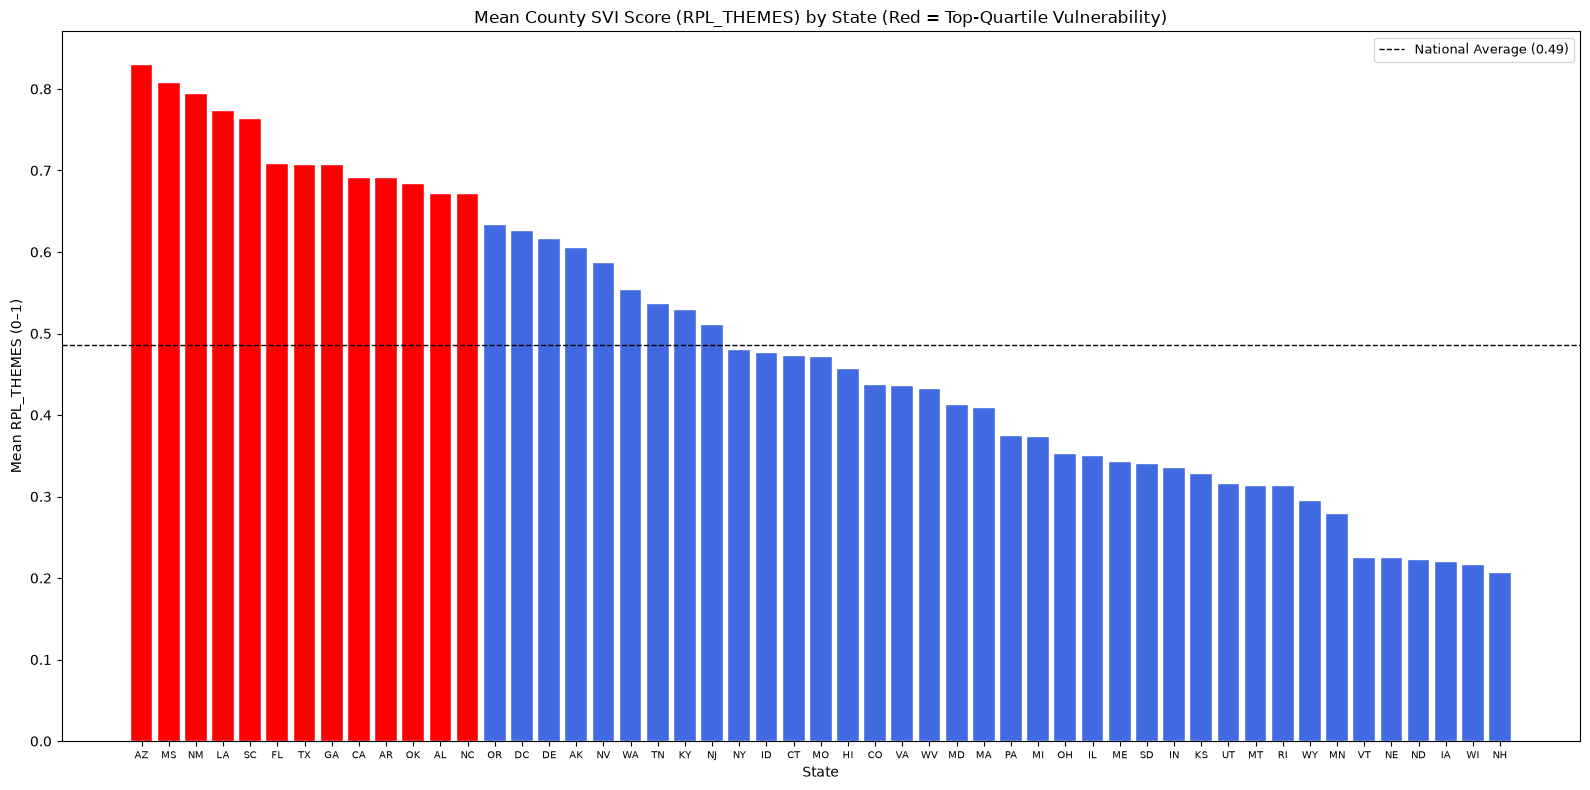

In [15]:
# Visualization 3: State-Level Mean Social Vulnerability

state_svi = (
    df.groupby("ST_ABBR")["RPL_THEMES"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

nat_avg = state_svi["RPL_THEMES"].mean()
q75     = state_svi["RPL_THEMES"].quantile(0.75)

colors = ["red" if v >= q75 else "royalblue" for v in state_svi["RPL_THEMES"]]

fig, ax = plt.subplots(figsize=(16, 8))
ax.bar(state_svi["ST_ABBR"], state_svi["RPL_THEMES"],
       color=colors, edgecolor="white", linewidth=0.3)
ax.axhline(nat_avg, color="black", linestyle="--", linewidth=1,
           label=f"National Average ({nat_avg:.2f})")
ax.set_title("Mean County SVI Score (RPL_THEMES) by State (Red = Top-Quartile Vulnerability)",
             fontsize=12)
ax.set_xlabel("State")
ax.set_ylabel("Mean RPL_THEMES (0–1)")
ax.tick_params(axis="x", labelsize=7)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Key Observations for Visualization 3:**
- Southern and Gulf Coast states (Mississippi, Louisiana, New Mexico, Arkansas, South Carolina) have the highest mean county-level SVI score.
- There's a drop off after North Carolina, after which no state exceeds the national average of 0.49.
- New England and Upper Midwest states (Vermont, New Hampshire, Minnesota, Wisconsin) have the lowest mean county-level SVI score.

In [16]:
# Visualization 4: US Census Region Map
# Shows the 4 Census Bureau regions used as geographic feature in the model

region_df = pd.DataFrame(list(region_map.items()), columns=["ST_ABBR", "REGION"])

fig = px.choropleth(
    region_df,
    locations="ST_ABBR",
    locationmode="USA-states",
    color="REGION",
    scope="usa",
    title="US Census Bureau Regions (Geographic Feature)",
    color_discrete_map={
        "Northeast": "#4e79a7",
        "Midwest":   "#f28e2b",
        "South":     "#e15759",
        "West":      "#76b7b2",
    },
    hover_name="ST_ABBR",
    hover_data={"ST_ABBR": False, "REGION": True}
)
fig.update_layout(
    legend_title_text="Region",
    geo_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)"
)
fig.show()

## Label Engineering

In [17]:
# LABEL ENGINEERING THE TARGET VARIABLE
# No direct data on county-level PMOS underdiagnosis in any dataset
# Approach: Construct a composite binary label from three "signals" grounded in literature
# ICD rates excluded due to underestimation of true PMOS prevalence (Neven)

# Signal 1: High SVI (Silva)
# Signal 2: Low preventative healthcare engagement (Silva)
# Signal 3: High NCHS code (Ramphul)

# Social Vulnerablility + Access
# Composite Label: Signal 1 AND (Signal 2 OR 3)
# Two potential pathways to define underdiagnosis:
#   A: Vulnerable + disengaged from healthcare (Silva)
#   B: Vulnerable + geographically isolated (Ramphul)

# Signal 1 - in top-quartile social vulnerability
svi_high = df["RPL_THEMES"] >= df["RPL_THEMES"].quantile(0.75)

# Signal 2 - low preventative healthcare engagement
# Cervical screening (CERVICAL) unavailabile in PLACES 2025
# due to survey question change, replaced with mammography
checkup_col = "ANNUAL_CHECKUP"
mammography_col = "MAMMOGRAPHY"

preventative_low = (
    (df[checkup_col] <= df[checkup_col].quantile(0.25)) |
     (df[mammography_col] <= df[mammography_col].quantile(0.25))
)

# Signal 3: rural/periurban area (NCHS code >= 4)
rural_high = df["RURAL_CODE"] >= 4

# Composite binary label - returns 0 (low risk) or 1 (high risk)
df["UNDERDIAGNOSIS_RISK"] = (
    svi_high & (preventative_low | rural_high)
).astype(int)

# Check distribution, aim for 20-35% positive rate
counts = df["UNDERDIAGNOSIS_RISK"].value_counts()
positive_rate = counts[1] / len(df) * 100
print(f"High-risk counties (label = 1): {counts[1]}")
print(f"Low-risk counties (label = 0): {counts[0]}")
print(f"Positive rate: {positive_rate:.1f}%")

High-risk counties (label = 1): 671
Low-risk counties (label = 0): 2473
Positive rate: 21.3%


## Defining Features & Train/Test Split

In [18]:
# DROPPING all RPL_THEMES
# DEFINE FEATURES(X) AND TARGET(Y)
# Exclude identifier columns and the target variable itself from features


leak_cols = ['UNDERDIAGNOSIS_RISK', 'FIPS', 'COUNTY', 'ST_ABBR',
             'RPL_THEMES', 'ANNUAL_CHECKUP', 'MAMMOGRAPHY', 'RURAL_CODE',
             'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4']

X = df.drop(columns=leak_cols)
y = df['UNDERDIAGNOSIS_RISK']


# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Features included ({X.shape[1]}): {X.columns.tolist()}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Features included (20): ['EP_NOVEH', 'EP_AFAM', 'EP_UNINSUR', 'EP_LIMENG', 'EP_POV150', 'EP_UNEMP', 'EP_NOHSDP', 'EP_HISP', 'EP_MUNIT', 'EP_HBURD', 'EP_DISABL', 'EP_MINRTY', 'DEPRESSION_PREV', 'DIABETES_PREV', 'FOOD_INSECURITY', 'HIGH_CHOL_PREV', 'OBESITY_PREV', 'REGION_Northeast', 'REGION_South', 'REGION_West']
X_train shape: (2515, 20)
X_test shape: (629, 20)
y_train shape: (2515,)
y_test shape: (629,)


## Train Models

### First Random Forest Model

------------- Random Forest First Model -------------
              precision    recall  f1-score   support

    Low Risk       0.94      0.92      0.93       495
   High Risk       0.73      0.80      0.76       134

    accuracy                           0.90       629
   macro avg       0.84      0.86      0.85       629
weighted avg       0.90      0.90      0.90       629



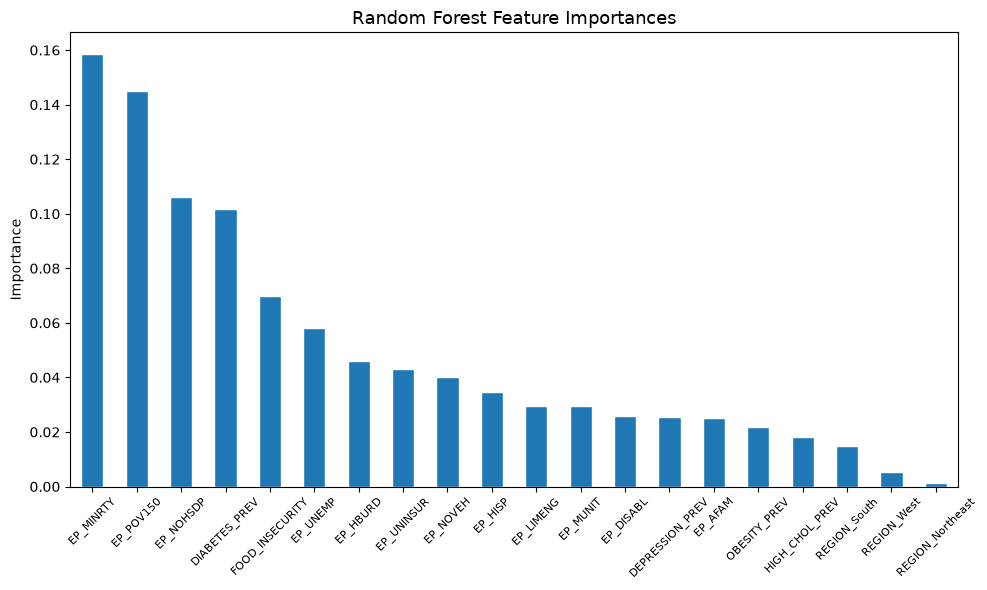


Top 10 features:
EP_MINRTY          0.158587
EP_POV150          0.145109
EP_NOHSDP          0.106222
DIABETES_PREV      0.101564
FOOD_INSECURITY    0.069676
EP_UNEMP           0.058294
EP_HBURD           0.045987
EP_UNINSUR         0.043247
EP_NOVEH           0.040107
EP_HISP            0.034584
dtype: float64


In [19]:
# Train Random Forest

rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("------------- Random Forest First Model -------------")
print(classification_report(y_test, y_pred_rf, target_names=["Low Risk", "High Risk"]))

# Feature importance plot
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Random Forest Feature Importances", fontsize=13)
ax.set_ylabel("Importance")
ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.show()
print("\nTop 10 features:")
print(importances.head(10))

In [20]:
# Overfitting Check for Random Forest
print("------------- Random Forest First Model (Train) -------------")
print(classification_report(y_train, rf.predict(X_train), target_names=["Low Risk", "High Risk"]))

print("------------- Random Forest First Model (Test) -------------")
print(classification_report(y_test, rf.predict(X_test), target_names=["Low Risk", "High Risk"]))

------------- Random Forest First Model (Train) -------------
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      1978
   High Risk       0.98      1.00      0.99       537

    accuracy                           1.00      2515
   macro avg       0.99      1.00      0.99      2515
weighted avg       1.00      1.00      1.00      2515

------------- Random Forest First Model (Test) -------------
              precision    recall  f1-score   support

    Low Risk       0.94      0.92      0.93       495
   High Risk       0.73      0.80      0.76       134

    accuracy                           0.90       629
   macro avg       0.84      0.86      0.85       629
weighted avg       0.90      0.90      0.90       629



### Refined Random Forest Model

In [21]:
# New Random Forest Model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

param_dist = {
    "max_depth": [4, 6, 8, 10, None],  # limits the depth of the random forest tree
    "min_samples_leaf": [1, 3, 5, 10], # limits the min counties in the tree's leaf
    "min_samples_split": [2, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5],
    "n_estimators": [100, 200, 300], # how many tress to build
}

# picks 30 random combinations using the param_dist & trains 5 separate models and avg scores
new_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    scoring=f2_scorer,
    cv=cv,
    random_state=42,
    n_jobs=-1
)

new_rf.fit(X_train, y_train)
print(new_rf.best_params_)

y_pred_rf_ref = new_rf.predict(X_test)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 10}


In [189]:
# New Random Forest Model Result
print("------------- Random Forest Refined Model (Train) -------------")
print(classification_report(y_train, new_rf.predict(X_train), target_names=["Low Risk", "High Risk"]))

print("------------- Random Forest Refined Model (Test) -------------")
print(classification_report(y_test, new_rf.predict(X_test), target_names=["Low Risk", "High Risk"]))

------------- Random Forest Refined Model (Train) -------------
              precision    recall  f1-score   support

    Low Risk       1.00      0.95      0.98      1978
   High Risk       0.85      1.00      0.92       537

    accuracy                           0.96      2515
   macro avg       0.93      0.98      0.95      2515
weighted avg       0.97      0.96      0.96      2515

------------- Random Forest Refined Model (Test) -------------
              precision    recall  f1-score   support

    Low Risk       0.95      0.89      0.92       495
   High Risk       0.68      0.84      0.76       134

    accuracy                           0.88       629
   macro avg       0.82      0.87      0.84       629
weighted avg       0.90      0.88      0.89       629



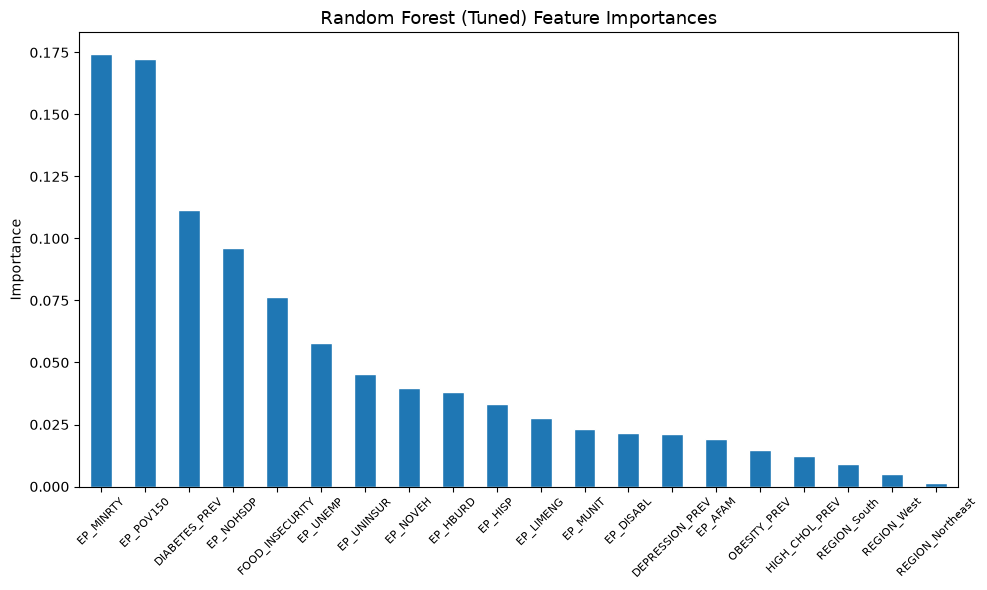


Top 10 features:
EP_MINRTY          0.174381
EP_POV150          0.172162
DIABETES_PREV      0.111590
EP_NOHSDP          0.096052
FOOD_INSECURITY    0.076295
EP_UNEMP           0.057661
EP_UNINSUR         0.045429
EP_NOVEH           0.039652
EP_HBURD           0.038123
EP_HISP            0.033169
dtype: float64


In [22]:
# New Random Forest Feature importance plot
importances = pd.Series(new_rf.best_estimator_.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Random Forest (Tuned) Feature Importances", fontsize=13)
ax.set_ylabel("Importance")
ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importances.head(10))

In [23]:
fig = px.choropleth(
    state_svi,
    locations='ST_ABBR',
    locationmode='USA-states',
    color='RPL_THEMES',
    scope='usa',
    color_continuous_scale='Viridis_r',
    title='Mean County SVI Score (RPL_THEMES) by State',
    hover_name='ST_ABBR',
    hover_data={'RPL_THEMES': ':.2f'}
)

fig.update_layout(
    geo_scope='usa',
    geo_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)'
)

fig.show()

### Logistic Regression Model

In [41]:
# Train Logistic Regression on Top 10 Features

top10 = importances.head(10).index.tolist()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[top10])
X_test_scaled  = scaler.transform(X_test[top10])

lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("------------- Logistic Regression (top 10 features) -------------")
print(classification_report(y_test, y_pred_lr, target_names=["Low Risk", "High Risk"]))

------------- Logistic Regression (top 10 features) -------------
              precision    recall  f1-score   support

    Low Risk       0.95      0.85      0.90       495
   High Risk       0.61      0.85      0.71       134

    accuracy                           0.85       629
   macro avg       0.78      0.85      0.81       629
weighted avg       0.88      0.85      0.86       629



In [42]:
# Overfitting Check for Logistic Regression
print("------------- Logistic Regression (Train) -------------")
print(classification_report(y_train, lr.predict(X_train_scaled), target_names=["Low Risk", "High Risk"]))

print("------------- Logistic Regression (Test) -------------")
print(classification_report(y_test, lr.predict(X_test_scaled), target_names=["Low Risk", "High Risk"]))

------------- Logistic Regression (Train) -------------
              precision    recall  f1-score   support

    Low Risk       0.96      0.87      0.92      1978
   High Risk       0.65      0.88      0.75       537

    accuracy                           0.87      2515
   macro avg       0.81      0.87      0.83      2515
weighted avg       0.90      0.87      0.88      2515

------------- Logistic Regression (Test) -------------
              precision    recall  f1-score   support

    Low Risk       0.95      0.85      0.90       495
   High Risk       0.61      0.85      0.71       134

    accuracy                           0.85       629
   macro avg       0.78      0.85      0.81       629
weighted avg       0.88      0.85      0.86       629



### First XGBoost Model

In [26]:
# Train XGBoost

spw = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(scale_pos_weight=spw, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("------------- XGBoost First Model -------------")
print(classification_report(y_test, y_pred_xgb, target_names=["Low Risk", "High Risk"]))

------------- XGBoost First Model -------------
              precision    recall  f1-score   support

    Low Risk       0.95      0.94      0.95       495
   High Risk       0.79      0.81      0.80       134

    accuracy                           0.91       629
   macro avg       0.87      0.87      0.87       629
weighted avg       0.91      0.91      0.91       629



In [27]:
# Overfitting check for XGBoost
print("------------- XGBoost First Model (Train) -------------")
print(classification_report(y_train, xgb.predict(X_train), target_names=["Low Risk", "High Risk"]))

print("------------- XGBoost First Model (Test) -------------")
print(classification_report(y_test, xgb.predict(X_test), target_names=["Low Risk", "High Risk"]))

------------- XGBoost First Model (Train) -------------
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      1978
   High Risk       1.00      1.00      1.00       537

    accuracy                           1.00      2515
   macro avg       1.00      1.00      1.00      2515
weighted avg       1.00      1.00      1.00      2515

------------- XGBoost First Model (Test) -------------
              precision    recall  f1-score   support

    Low Risk       0.95      0.94      0.95       495
   High Risk       0.79      0.81      0.80       134

    accuracy                           0.91       629
   macro avg       0.87      0.87      0.87       629
weighted avg       0.91      0.91      0.91       629



### Refined XGBoost Model

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)          # for threshold tuning
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)     # for nested CV
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)     # for nested CV

# ensures that the minority group of counties have mistakes cost more
spw = (y_train == 0).sum() / (y_train == 1).sum()

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)          # for threshold tuning
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)     # for nested CV
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)     # for nested CV

# ensures that the minority group of counties have mistakes cost more
spw = (y_train == 0).sum() / (y_train == 1).sum()

# regularized model with early stopping to find a good n_estimators value
# implement early stopping to help prevent overfitting
xgb_early = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2,
    scale_pos_weight=spw,
    early_stopping_rounds=20,
    eval_metric="logloss",
    random_state=42
)
xgb_early.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print(f"Best iteration (n_estimators to use going forward): {xgb_early.best_iteration}")

Best iteration (n_estimators to use going forward): 291


In [30]:
# build the model with n_estimators fixed and no early stopping
# this version is safe to use in
# cross_val_predict / cross_val_score / any CV-based step
xgb_model = XGBClassifier(
    n_estimators=xgb_early.best_iteration,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2,
    scale_pos_weight=spw,
    eval_metric="logloss",
    random_state=42
)
xgb_model.fit(X_train, y_train)

y_pred_xgb_ref = xgb_model.predict(X_test)

In [31]:
# overfitting check
print("------------- XGBoost Refined Model (Train) -------------")
print(classification_report(y_train, xgb_model.predict(X_train), target_names=["Low Risk","High Risk"]))

print("------------- XGBoost Refined Model (Test) -------------")
print(classification_report(y_test, xgb_model.predict(X_test), target_names=["Low Risk","High Risk"]))

------------- XGBoost Refined Model (Train) -------------
              precision    recall  f1-score   support

    Low Risk       1.00      0.96      0.98      1978
   High Risk       0.86      1.00      0.92       537

    accuracy                           0.96      2515
   macro avg       0.93      0.98      0.95      2515
weighted avg       0.97      0.96      0.97      2515

------------- XGBoost Refined Model (Test) -------------
              precision    recall  f1-score   support

    Low Risk       0.96      0.92      0.94       495
   High Risk       0.74      0.87      0.80       134

    accuracy                           0.91       629
   macro avg       0.85      0.90      0.87       629
weighted avg       0.92      0.91      0.91       629



In [32]:
# threshold tuning (F2-optimized via training CV,
# applied once to the test set)
def tune_threshold(model, X_tr, y_tr, X_te, y_te, cv):
    # trains on different folds
    train_probs = cross_val_predict(model, X_tr, y_tr, cv=cv, method="predict_proba")[:, 1]
    # finds best cutoff
    precision, recall, thresholds = precision_recall_curve(y_tr, train_probs)
    f2 = (5 * precision * recall) / (4 * precision + recall + 1e-10)
    best_threshold = thresholds[np.argmax(f2)]

    test_probs = model.predict_proba(X_te)[:, 1]
    y_pred = (test_probs >= best_threshold).astype(int)
    print(f"Threshold: {best_threshold:.3f}")
    print(classification_report(y_te, y_pred, target_names=["Low Risk","High Risk"]))
    return best_threshold, test_probs

print("------------- XGBoost Refined Model (Tuned) threshold -------------")
xgb_threshold, xgb_probs = tune_threshold(xgb_model, X_train, y_train, X_test, y_test, cv)

------------- XGBoost Refined Model (Tuned) threshold -------------
Threshold: 0.281
              precision    recall  f1-score   support

    Low Risk       0.98      0.87      0.92       495
   High Risk       0.65      0.93      0.77       134

    accuracy                           0.88       629
   macro avg       0.81      0.90      0.84       629
weighted avg       0.91      0.88      0.89       629



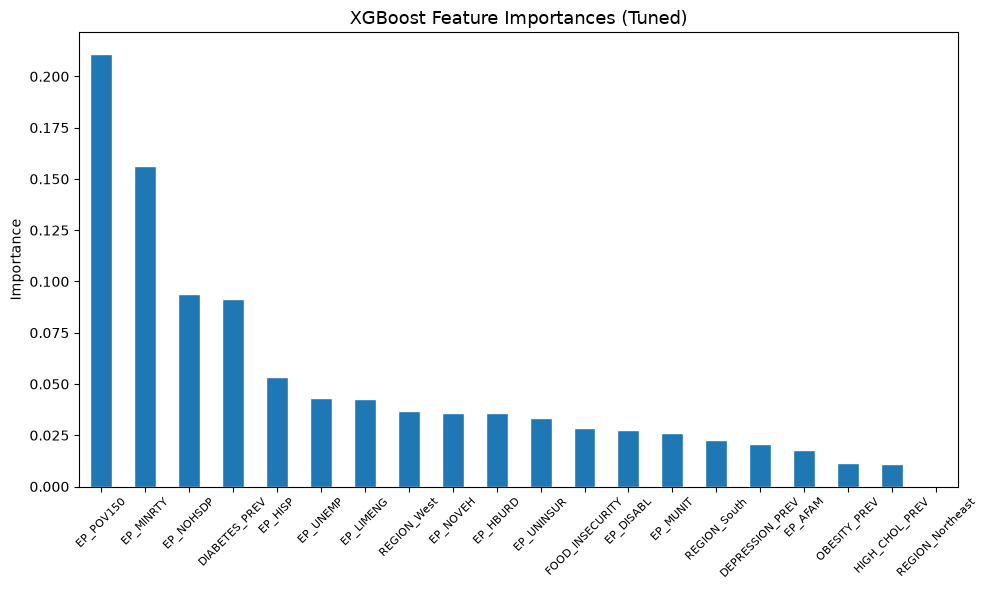


Top 10 features:
EP_POV150        0.210948
EP_MINRTY        0.156494
EP_NOHSDP        0.093707
DIABETES_PREV    0.091295
EP_HISP          0.053197
EP_UNEMP         0.043319
EP_LIMENG        0.042796
REGION_West      0.037062
EP_NOVEH         0.035754
EP_HBURD         0.035697
dtype: float32


In [33]:
# top 10 features
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("XGBoost Feature Importances (Tuned)", fontsize=13)
ax.set_ylabel("Importance")
ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importances.head(10))

## Model Validation

### Validation on First Models 

In [39]:
# 5 cross fold for RF and XGboost with tuning (for first models)
def cv_recall_at_tuned_threshold(model, X, y, outer_cv, inner_cv):
    recalls, precisions, thresholds_used = [], [], []

    for train_idx, test_idx in outer_cv.split(X, y):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        # INNER step: get honest out-of-fold probabilities on the training portion only
        inner_probs = cross_val_predict(model, X_tr, y_tr, cv=inner_cv, method="predict_proba")[:, 1]
        prec, rec, thresh = precision_recall_curve(y_tr, inner_probs)
        f2 = (5 * prec * rec) / (4 * prec + rec + 1e-10)
        best_thresh = thresh[np.argmax(f2)]
        thresholds_used.append(best_thresh)

        # fit on the FULL training fold, then evaluate on the held-out outer fold
        model.fit(X_tr, y_tr)
        probs_te = model.predict_proba(X_te)[:, 1]
        y_pred = (probs_te >= best_thresh).astype(int)

        recalls.append(recall_score(y_te, y_pred))
        precisions.append(precision_score(y_te, y_pred))

    print(f"Thresholds per fold: {[f'{t:.3f}' for t in thresholds_used]}")
    print(f"Recall: {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
    print(f"Precision: {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("------------- Random Forest First Model Nested CV -------------")
cv_recall_at_tuned_threshold(rf, X, y, outer_cv, inner_cv)

print("------------- XGBoost First Model Nested CV -------------")
cv_recall_at_tuned_threshold(xgb, X, y, outer_cv, inner_cv)

------------- Random Forest First Model Nested CV -------------
Thresholds per fold: ['0.360', '0.290', '0.310', '0.290', '0.400']
Recall: 0.931 ± 0.023
Precision: 0.659 ± 0.032
------------- XGBoost First Model Nested CV -------------
Thresholds per fold: ['0.051', '0.031', '0.038', '0.016', '0.069']
Recall: 0.940 ± 0.022
Precision: 0.662 ± 0.025


In [44]:
# MODEL COMPARISON SUMMARY
# Accuracy: overall correct predictions
# F1 (high-risk): mean of precision + recall for high-risk class
# ROC-AUC: 0.5 = random chance, 1.0 = perfect separation

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

summary = pd.DataFrame({
    "Model": ["Random Forest","Logistic Regression", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "F1 (High-Risk)": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb),
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]),
    ]
})

print("------------- MODEL COMPARISON SUMMARY -------------")
print(summary.round(3).to_string(index=False))

------------- MODEL COMPARISON SUMMARY -------------
              Model  Accuracy  F1 (High-Risk)  ROC-AUC
      Random Forest     0.895           0.764    0.996
Logistic Regression     0.852           0.710    0.933
            XGBoost     0.914           0.800    0.997


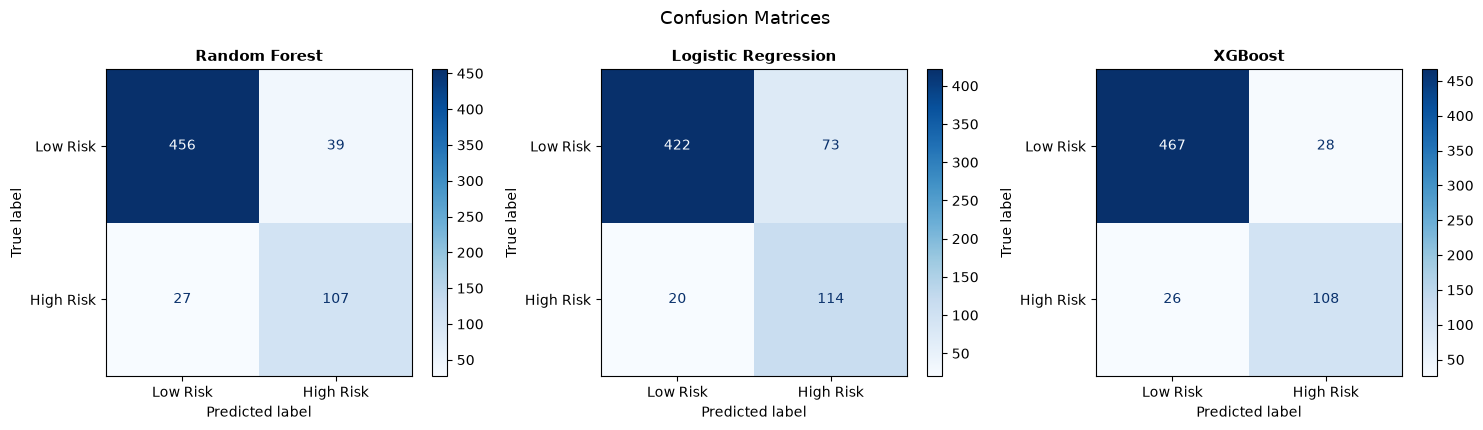

In [45]:
# Confusion Matrices
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, [
    ("Random Forest",       y_pred_rf),
    ("Logistic Regression", y_pred_lr),
    ("XGBoost",             y_pred_xgb),
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Low Risk", "High Risk"],
        cmap="Blues", ax=ax
    )
    ax.set_title(name, fontsize=11, fontweight="bold")
plt.suptitle("Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

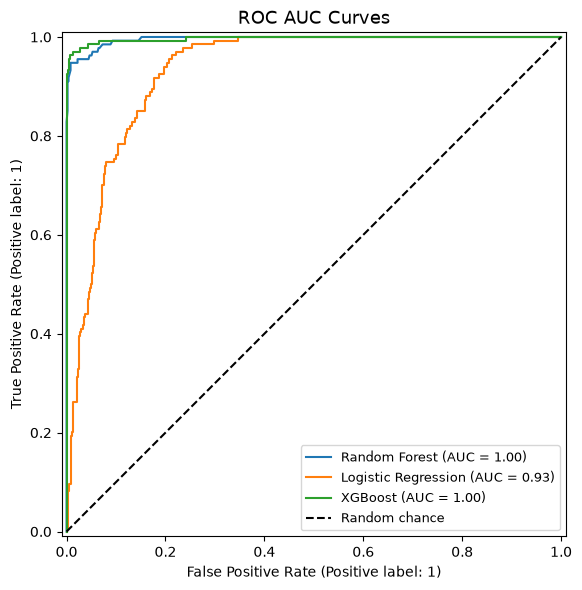

In [46]:
# ROC AUC Curves

fig, ax = plt.subplots(figsize=(7, 6))
for name, y_prob in [
    ("Random Forest",       rf.predict_proba(X_test)[:, 1]),
    ("Logistic Regression", lr.predict_proba(X_test_scaled)[:, 1]),
    ("XGBoost",             xgb.predict_proba(X_test)[:, 1]),
]:
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random chance")
ax.set_title("ROC AUC Curves", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Validation on Refined Models

In [47]:
# nested cross validation
def cv_recall_at_tuned_threshold(model, X, y, outer_cv, inner_cv):
    recalls, precisions, thresholds_used = [], [], []

    for train_idx, test_idx in outer_cv.split(X, y):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        inner_probs = cross_val_predict(model, X_tr, y_tr, cv=inner_cv, method="predict_proba")[:, 1]
        prec, rec, thresh = precision_recall_curve(y_tr, inner_probs)
        f2 = (5 * prec * rec) / (4 * prec + rec + 1e-10)
        best_thresh = thresh[np.argmax(f2)]
        thresholds_used.append(best_thresh)

        model.fit(X_tr, y_tr)
        probs_te = model.predict_proba(X_te)[:, 1]
        y_pred = (probs_te >= best_thresh).astype(int)

        recalls.append(recall_score(y_te, y_pred))
        precisions.append(precision_score(y_te, y_pred))

    print(f"Thresholds per fold: {[f'{t:.3f}' for t in thresholds_used]}")
    print(f"Recall: {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
    print(f"Precision: {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")

print("------------- XGBoost Refined Model Nested CV -------------")
cv_recall_at_tuned_threshold(xgb_model, X, y, outer_cv, inner_cv)

------------- XGBoost Refined Model Nested CV -------------
Thresholds per fold: ['0.242', '0.398', '0.226', '0.239', '0.304']
Recall: 0.949 ± 0.025
Precision: 0.682 ± 0.033


In [52]:
# MODEL COMPARISON SUMMARY (Refined Models)
# Accuracy: overall correct predictions
# F1 (high-risk): mean of precision + recall for high-risk class
# ROC-AUC: 0.5 = random chance, 1.0 = perfect separation

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

summary = pd.DataFrame({
    "Model": ["Random Forest","Logistic Regression", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf_ref),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb_ref)
    ],
    "F1 (High-Risk)": [
        f1_score(y_test, y_pred_rf_ref),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb_ref),
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, new_rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]),
    ]
})

print("------------- MODEL COMPARISON SUMMARY (Refined Models) -------------")
print(summary.round(3).to_string(index=False))

------------- MODEL COMPARISON SUMMARY (Refined Models) -------------
              Model  Accuracy  F1 (High-Risk)  ROC-AUC
      Random Forest     0.884           0.756    0.954
Logistic Regression     0.852           0.710    0.933
            XGBoost     0.908           0.801    0.987


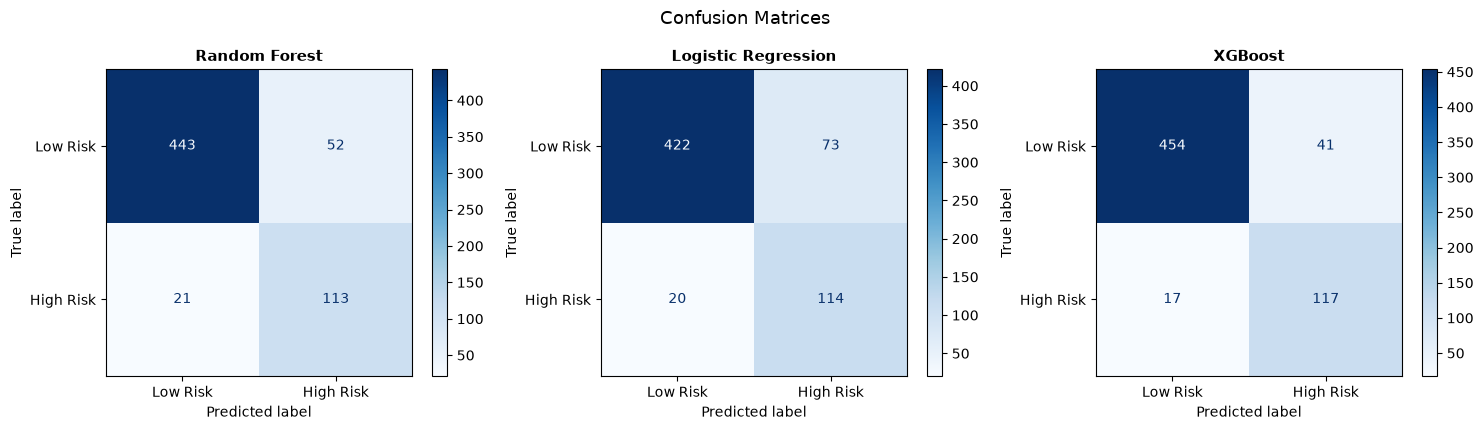

In [50]:
# Confusion Matrices (Refined Models)
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, [
    ("Random Forest",       y_pred_rf_ref),
    ("Logistic Regression", y_pred_lr),
    ("XGBoost",             y_pred_xgb_ref),
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Low Risk", "High Risk"],
        cmap="Blues", ax=ax
    )
    ax.set_title(name, fontsize=11, fontweight="bold")
plt.suptitle("Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

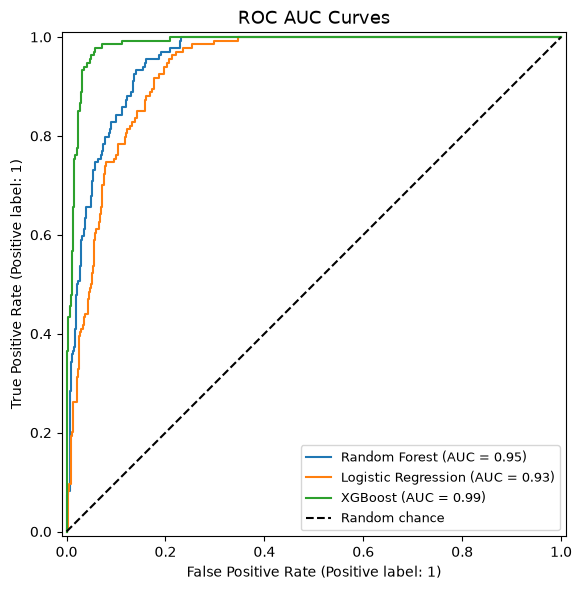

In [51]:
# ROC AUC Curves (Refined Models)

fig, ax = plt.subplots(figsize=(7, 6))
for name, y_prob in [
    ("Random Forest",       new_rf.predict_proba(X_test)[:, 1]),
    ("Logistic Regression", lr.predict_proba(X_test_scaled)[:, 1]),
    ("XGBoost",             xgb_model.predict_proba(X_test)[:, 1]),
]:
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random chance")
ax.set_title("ROC AUC Curves", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Fairness Audits

In [55]:
# SYSTEMIC BIAS AUDIT
# Checks whether model systematically misses high-risk counties in
# ones with high minority/Black/poverty populations
# Higher False Negative Rate (FNR) = structural bias/inequity

### Audits on First Models

In [61]:
# Logistic Regression Model 
# Attach demographic context/predictions to test set
test_idx = X_test.index
bias_df = df.loc[test_idx,["COUNTY", "ST_ABBR", "EP_AFAM", "EP_MINRTY",
                            "EP_POV150"]].copy()
bias_df["TRUE_LABEL"] = y_test.values
bias_df["RF_PREDICTION"] = y_pred_lr
bias_df["RF_PROB"] = lr.predict_proba(X_test_scaled)[:,1]

# Split counties into high/low groups by national median
for col, label in [("EP_MINRTY", "HIGH_MINORITY"),
                   ("EP_AFAM", "HIGH_BLACK"),
                   ("EP_POV150", "HIGH_POVERTY")]:
    bias_df[label] = (bias_df[col] > bias_df[col]
                                     .median()).astype(int)
def fnr(group_df):
  truly_high = group_df[group_df["TRUE_LABEL"] == 1]
  if len(truly_high) == 0:
    return np.nan
  return (truly_high["RF_PREDICTION"]==0).mean()

print("----- FAIRNESS AUDIT: FALSE NEGATIVE RATES (FNR) BY DEMOGRAPHIC GROUP -----")
print("------------- Logistic Regression Model -------------")
print("Higher FNR = model misses more high-risk counties in that group\n")

for group_col, label in [("HIGH_MINORITY", "Minority Population"),
                         ("HIGH_BLACK", "Black Population"),
                         ("HIGH_POVERTY", "Poverty Rate")]:
    for val, name in [(0, "Low"), (1, "High")]:
      subset = bias_df[bias_df[group_col] == val]
      rate = fnr(subset)
      f1 = f1_score(subset["TRUE_LABEL"], subset["RF_PREDICTION"],
                    zero_division=0)
      print(f"{label} - {name}: FNR={rate:.3f}, F1={f1:.3f} (n={len(subset)})")
      print()
print("If FNR is significantly higher in high-minorty/poverty counties = ")
print("the model is systematically missing highly-vulnerable populations.")
print("\nPlease evaluate further for sources of systematic bias.")



----- FAIRNESS AUDIT: FALSE NEGATIVE RATES (FNR) BY DEMOGRAPHIC GROUP -----
------------- Logistic Regression Model -------------
Higher FNR = model misses more high-risk counties in that group

Minority Population - Low: FNR=0.467, F1=0.471 (n=315)

Minority Population - High: FNR=0.109, F1=0.739 (n=314)

Black Population - Low: FNR=0.116, F1=0.731 (n=317)

Black Population - High: FNR=0.165, F1=0.700 (n=312)

Poverty Rate - Low: FNR=0.333, F1=0.545 (n=317)

Poverty Rate - High: FNR=0.136, F1=0.722 (n=312)

If FNR is significantly higher in high-minorty/poverty counties = 
the model is systematically missing highly-vulnerable populations.

Please evaluate further for sources of systematic bias.


In [57]:
# First Random Forest Model 
# Attach demographic context/predictions to test set
test_idx = X_test.index
bias_df = df.loc[test_idx,["COUNTY", "ST_ABBR", "EP_AFAM", "EP_MINRTY",
                            "EP_POV150"]].copy()
bias_df["TRUE_LABEL"] = y_test.values
bias_df["RF_PREDICTION"] = y_pred_rf
bias_df["RF_PROB"] = rf.predict_proba(X_test)[:,1]

# Split counties into high/low groups by national median
for col, label in [("EP_MINRTY", "HIGH_MINORITY"),
                   ("EP_AFAM", "HIGH_BLACK"),
                   ("EP_POV150", "HIGH_POVERTY")]:
    bias_df[label] = (bias_df[col] > bias_df[col]
                                     .median()).astype(int)
def fnr(group_df):
  truly_high = group_df[group_df["TRUE_LABEL"] == 1]
  if len(truly_high) == 0:
    return np.nan
  return (truly_high["RF_PREDICTION"]==0).mean()

print("----- FAIRNESS AUDIT: FALSE NEGATIVE RATES (FNR) BY DEMOGRAPHIC GROUP -----")
print("------------- First Random Forest Model -------------")
print("Higher FNR = model misses more high-risk counties in that group\n")

for group_col, label in [("HIGH_MINORITY", "Minority Population"),
                         ("HIGH_BLACK", "Black Population"),
                         ("HIGH_POVERTY", "Poverty Rate")]:
    for val, name in [(0, "Low"), (1, "High")]:
      subset = bias_df[bias_df[group_col] == val]
      rate = fnr(subset)
      f1 = f1_score(subset["TRUE_LABEL"], subset["RF_PREDICTION"],
                    zero_division=0)
      print(f"{label} - {name}: FNR={rate:.3f}, F1={f1:.3f} (n={len(subset)})")
      print()
print("If FNR is significantly higher in high-minorty/poverty counties = ")
print("the model is systematically missing highly-vulnerable populations.")
print("\nPlease evaluate further for sources of systematic bias.")



----- FAIRNESS AUDIT: FALSE NEGATIVE RATES (FNR) BY DEMOGRAPHIC GROUP -----
------------- First Random Forest Model -------------
Higher FNR = model misses more high-risk counties in that group

Minority Population - Low: FNR=0.800, F1=0.333 (n=315)

Minority Population - High: FNR=0.126, F1=0.794 (n=314)

Black Population - Low: FNR=0.279, F1=0.765 (n=317)

Black Population - High: FNR=0.165, F1=0.764 (n=312)

Poverty Rate - Low: FNR=0.444, F1=0.714 (n=317)

Poverty Rate - High: FNR=0.184, F1=0.767 (n=312)

If FNR is significantly higher in high-minorty/poverty counties = 
the model is systematically missing highly-vulnerable populations.

Please evaluate further for sources of systematic bias.


In [59]:
# First XGBoost Model
# Attach demographic context/predictions to test set
test_idx = X_test.index
bias_df = df.loc[test_idx,["COUNTY", "ST_ABBR", "EP_AFAM", "EP_MINRTY",
                            "EP_POV150"]].copy()
bias_df["TRUE_LABEL"] = y_test.values
bias_df["RF_PREDICTION"] = y_pred_xgb
bias_df["RF_PROB"] = xgb.predict_proba(X_test)[:,1]

# Split counties into high/low groups by national median
for col, label in [("EP_MINRTY", "HIGH_MINORITY"),
                   ("EP_AFAM", "HIGH_BLACK"),
                   ("EP_POV150", "HIGH_POVERTY")]:
    bias_df[label] = (bias_df[col] > bias_df[col]
                                     .median()).astype(int)
def fnr(group_df):
  truly_high = group_df[group_df["TRUE_LABEL"] == 1]
  if len(truly_high) == 0:
    return np.nan
  return (truly_high["RF_PREDICTION"]==0).mean()

print("----- FAIRNESS AUDIT: FALSE NEGATIVE RATES (FNR) BY DEMOGRAPHIC GROUP -----")
print("------------- First XGBoost Model -------------")
print("Higher FNR = model misses more high-risk counties in that group\n")

for group_col, label in [("HIGH_MINORITY", "Minority Population"),
                         ("HIGH_BLACK", "Black Population"),
                         ("HIGH_POVERTY", "Poverty Rate")]:
    for val, name in [(0, "Low"), (1, "High")]:
      subset = bias_df[bias_df[group_col] == val]
      rate = fnr(subset)
      f1 = f1_score(subset["TRUE_LABEL"], subset["RF_PREDICTION"],
                    zero_division=0)
      print(f"{label} - {name}: FNR={rate:.3f}, F1={f1:.3f} (n={len(subset)})")
      print()
print("If FNR is significantly higher in high-minorty/poverty counties = ")
print("the model is systematically missing highly-vulnerable populations.")
print("\nPlease evaluate further for sources of systematic bias.")



----- FAIRNESS AUDIT: FALSE NEGATIVE RATES (FNR) BY DEMOGRAPHIC GROUP -----
------------- First XGBoost Model -------------
Higher FNR = model misses more high-risk counties in that group

Minority Population - Low: FNR=0.733, F1=0.421 (n=315)

Minority Population - High: FNR=0.126, F1=0.829 (n=314)

Black Population - Low: FNR=0.163, F1=0.857 (n=317)

Black Population - High: FNR=0.209, F1=0.774 (n=312)

Poverty Rate - Low: FNR=0.556, F1=0.571 (n=317)

Poverty Rate - High: FNR=0.168, F1=0.812 (n=312)

If FNR is significantly higher in high-minorty/poverty counties = 
the model is systematically missing highly-vulnerable populations.

Please evaluate further for sources of systematic bias.


### Audits on Refined Models

In [ ]:
# Refined Random Forest Model 
#  Attach demographic context/predictions to test set
test_idx = X_test.index
bias_df = df.loc[test_idx,["COUNTY", "ST_ABBR", "EP_AFAM", "EP_MINRTY",
                            "EP_POV150"]].copy()
bias_df["TRUE_LABEL"] = y_test.values
bias_df["RF_PREDICTION"] = y_pred_rf_ref
bias_df["RF_PROB"] = new_rf.predict_proba(X_test)[:,1]

# Split counties into high/low groups by national median
for col, label in [("EP_MINRTY", "HIGH_MINORITY"),
                   ("EP_AFAM", "HIGH_BLACK"),
                   ("EP_POV150", "HIGH_POVERTY")]:
    bias_df[label] = (bias_df[col] > bias_df[col]
                                     .median()).astype(int)
def fnr(group_df):
  truly_high = group_df[group_df["TRUE_LABEL"] == 1]
  if len(truly_high) == 0:
    return np.nan
  return (truly_high["RF_PREDICTION"]==0).mean()

print("----- FAIRNESS AUDIT: FALSE NEGATIVE RATES (FNR) BY DEMOGRAPHIC GROUP -----")
print("------------- Refined Random Forest Model -------------")
print("Higher FNR = model misses more high-risk counties in that group\n")

for group_col, label in [("HIGH_MINORITY", "Minority Population"),
                         ("HIGH_BLACK", "Black Population"),
                         ("HIGH_POVERTY", "Poverty Rate")]:
    for val, name in [(0, "Low"), (1, "High")]:
      subset = bias_df[bias_df[group_col] == val]
      rate = fnr(subset)
      f1 = f1_score(subset["TRUE_LABEL"], subset["RF_PREDICTION"],
                    zero_division=0)
      print(f"{label} - {name}: FNR={rate:.3f}, F1={f1:.3f} (n={len(subset)})")
      print()
print("If FNR is significantly higher in high-minorty/poverty counties = ")
print("the model is systematically missing highly-vulnerable populations.")
print("\nPlease evaluate further for sources of systematic bias.")



----- FAIRNESS AUDIT: FALSE NEGATIVE RATES (FNR) BY DEMOGRAPHIC GROUP -----
------------- Refined Random Forest Model -------------
Higher FNR = model misses more high-risk counties in that group

Minority Population - Low: FNR=0.667, F1=0.476 (n=315)

Minority Population - High: FNR=0.092, F1=0.777 (n=314)

Black Population - Low: FNR=0.233, F1=0.750 (n=317)

Black Population - High: FNR=0.121, F1=0.758 (n=312)

Poverty Rate - Low: FNR=0.444, F1=0.556 (n=317)

Poverty Rate - High: FNR=0.136, F1=0.769 (n=312)

If FNR is significantly higher in high-minorty/poverty counties = 
the model is systematically missing highly-vulnerable populations.

Please evaluate further for sources of systematic bias.


In [63]:
# Refined XGBoost Model 
# Attach demographic context/predictions to test set
test_idx = X_test.index
bias_df = df.loc[test_idx,["COUNTY", "ST_ABBR", "EP_AFAM", "EP_MINRTY",
                            "EP_POV150"]].copy()
bias_df["TRUE_LABEL"] = y_test.values
bias_df["RF_PREDICTION"] = y_pred_xgb_ref
bias_df["RF_PROB"] = xgb_model.predict_proba(X_test)[:,1]

# Split counties into high/low groups by national median
for col, label in [("EP_MINRTY", "HIGH_MINORITY"),
                   ("EP_AFAM", "HIGH_BLACK"),
                   ("EP_POV150", "HIGH_POVERTY")]:
    bias_df[label] = (bias_df[col] > bias_df[col]
                                     .median()).astype(int)
def fnr(group_df):
  truly_high = group_df[group_df["TRUE_LABEL"] == 1]
  if len(truly_high) == 0:
    return np.nan
  return (truly_high["RF_PREDICTION"]==0).mean()

print("----- FAIRNESS AUDIT: FALSE NEGATIVE RATES (FNR) BY DEMOGRAPHIC GROUP -----")
print("------------- Refined XGBoost Model -------------")
print("Higher FNR = model misses more high-risk counties in that group\n")

for group_col, label in [("HIGH_MINORITY", "Minority Population"),
                         ("HIGH_BLACK", "Black Population"),
                         ("HIGH_POVERTY", "Poverty Rate")]:
    for val, name in [(0, "Low"), (1, "High")]:
      subset = bias_df[bias_df[group_col] == val]
      rate = fnr(subset)
      f1 = f1_score(subset["TRUE_LABEL"], subset["RF_PREDICTION"],
                    zero_division=0)
      print(f"{label} - {name}: FNR={rate:.3f}, F1={f1:.3f} (n={len(subset)})")
      print()
print("If FNR is significantly higher in high-minorty/poverty counties = ")
print("the model is systematically missing highly-vulnerable populations.")
print("\nPlease evaluate further for sources of systematic bias.")



----- FAIRNESS AUDIT: FALSE NEGATIVE RATES (FNR) BY DEMOGRAPHIC GROUP -----
------------- Refined XGBoost Model -------------
Higher FNR = model misses more high-risk counties in that group

Minority Population - Low: FNR=0.533, F1=0.583 (n=315)

Minority Population - High: FNR=0.076, F1=0.821 (n=314)

Black Population - Low: FNR=0.163, F1=0.818 (n=317)

Black Population - High: FNR=0.110, F1=0.794 (n=312)

Poverty Rate - Low: FNR=0.333, F1=0.800 (n=317)

Poverty Rate - High: FNR=0.112, F1=0.801 (n=312)

If FNR is significantly higher in high-minorty/poverty counties = 
the model is systematically missing highly-vulnerable populations.

Please evaluate further for sources of systematic bias.


## Data Drift Analysis 

DATA DRIFT ANALYSIS

-----PLACES 2024 v. 2025 (TESTED W/O REGION FEATURE 7/25/26)-----
- Re-ran pipeline against PLACES 2024
- (See "PLACES2024_ArchivedRun_CentralizedColabGroup14B.ipynb")
- to check and validate results using different PLACES data

- Metric | P2024 | P2025
- Label positive rate | 21.5% (677/3,144) | 21.5% (676/3,144)
- RF High-risk p/r/f1, acc | .85/.71/.77, .91 | .83/.78/.80, .92
- LR High-risk p/r/f1, acc | .77/.93/.84, .93 | .72/.95/.82, .91
- XGB High-risk p/r/f1, acc | .81/.79/.80, .92 | .81/.85/.83, .93

- CONCLUSION: label positive rate unchanged, high-risk F1 abs difference <= 0.03
- across models, not real accuracy gain for either release. PLACES 2025 used
- for more current data/clean merge, kept 2024 run for results validation

## Results

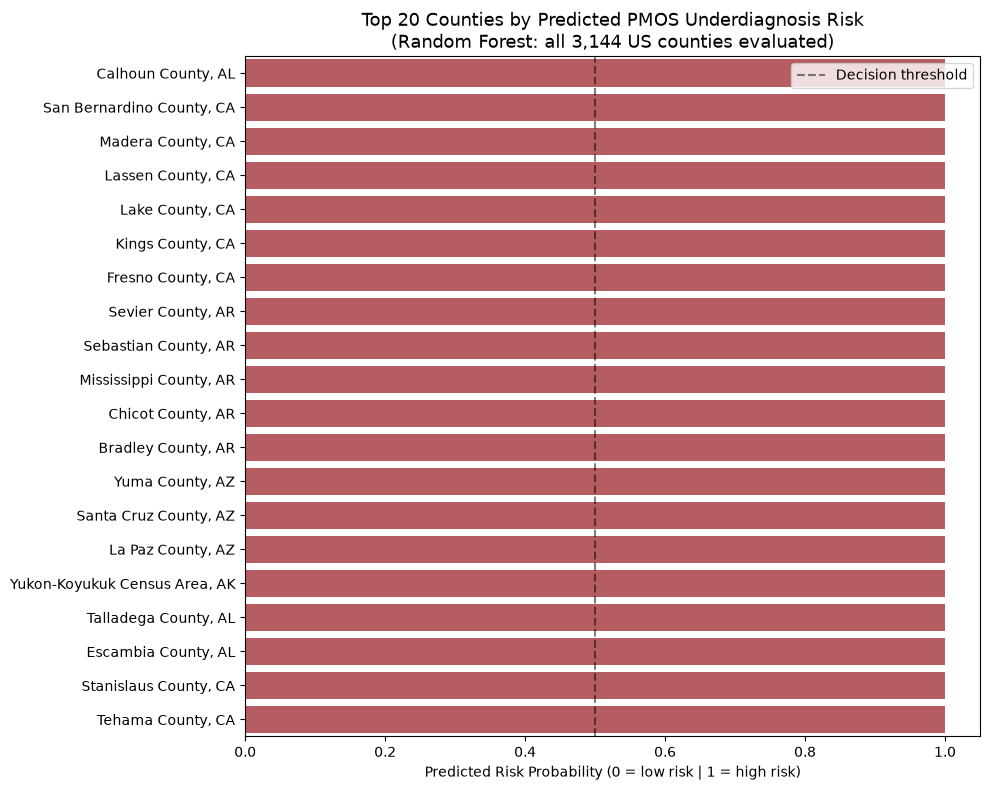

✅ SUCCESS: Full predicitons saved as pmos_predictions_all_counties.csv
Use saved file as input for Streamlit Deployment


In [64]:
# PRIMARY OUTPUT: TOP 20 HIGHEST-RISK COUNTIES FOR POLICY INTERVENTIONS
# Uses probability score for ranking (not binary label)
# Highlights counties public health resources and interventions should target first
# Saved CSV serves as input file for Streamlit Web App deployment

all_probs = rf.predict_proba(X)[:,1]
output_df = df[["FIPS", "COUNTY", "ST_ABBR"]].copy()
output_df["RISK_PROBABILITY"] = all_probs
output_df["PREDICTED_RISK"] = rf.predict(X)
output_df["TRUE_LABEL"] = y.values
output_df["label"] = output_df["COUNTY"] + ", " + output_df["ST_ABBR"]

top20 = output_df.nlargest(20, "RISK_PROBABILITY")

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=top20.sort_values("RISK_PROBABILITY"),
    y="label", x="RISK_PROBABILITY",
    color="#c44e52", ax=ax
)

ax.set_title("Top 20 Counties by Predicted PMOS Underdiagnosis Risk\n"
"(Random Forest: all 3,144 US counties evaluated)", fontsize=13)
ax.set_xlabel("Predicted Risk Probability (0 = low risk | 1 = high risk)")
ax.set_ylabel("")
ax.axvline(0.5, color="black", linestyle="--", alpha=0.5,
           label="Decision threshold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{DATASET_PATH}/top20_risk_counties.png", dpi=150)
plt.show()

# Save as CSV file for Streamlit deployment file
output_df.to_csv(f"{DATASET_PATH}/pmos_predictions_all_counties.csv",
                 index=False)
print("✅ SUCCESS: Full predicitons saved as pmos_predictions_all_counties.csv")
print("Use saved file as input for Streamlit Deployment")


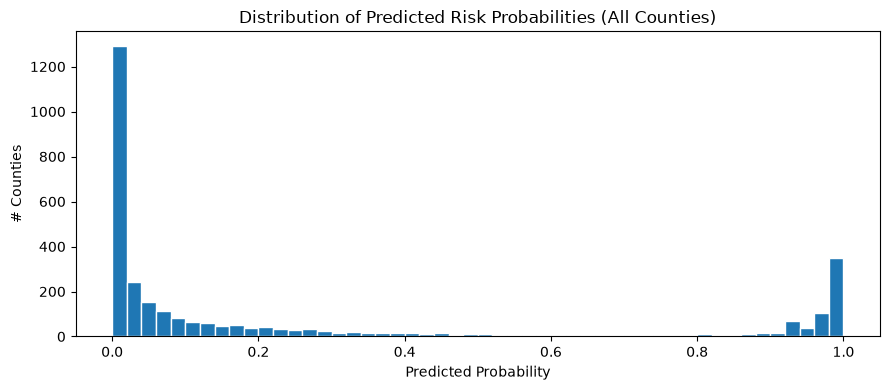

Counties with probability = 1.0: 152
Counties with probability > 0.5: 697

Top 20 counties — true label check:
                        label  RISK_PROBABILITY  TRUE_LABEL
           Calhoun County, AL               1.0           1
          Escambia County, AL               1.0           1
         Talladega County, AL               1.0           1
Yukon-Koyukuk Census Area, AK               1.0           1
            La Paz County, AZ               1.0           1
        Santa Cruz County, AZ               1.0           1
              Yuma County, AZ               1.0           1
           Bradley County, AR               1.0           1
            Chicot County, AR               1.0           1
       Mississippi County, AR               1.0           1
         Sebastian County, AR               1.0           1
            Sevier County, AR               1.0           1
            Fresno County, CA               1.0           1
             Kings County, CA               1.0  

In [65]:
# VALIDATING RISK PREDICTION PROBABILITY
# All top 20 counties show probability = 1.0 (every RF tree voted high-risk)
# Validate: are these true positives, and do their feature values justify certainty?

# 1. Probability distribution across all 3,144 counties
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(output_df["RISK_PROBABILITY"], bins=50, edgecolor="white")
ax.set_title("Distribution of Predicted Risk Probabilities (All Counties)", fontsize=12)
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("# Counties")
plt.tight_layout()
plt.show()

n_certain = (output_df["RISK_PROBABILITY"] == 1.0).sum()
print(f"Counties with probability = 1.0: {n_certain}")
print(f"Counties with probability > 0.5: {(output_df['RISK_PROBABILITY'] > 0.5).sum()}")

# 2. Confirm top 20 are all true positives
print("\nTop 20 counties — true label check:")
print(top20[["label", "RISK_PROBABILITY", "TRUE_LABEL"]].to_string(index=False))

# 3. Inspect key feature values for top 20 vs dataset average
top20_idx = top20.index
key_features = ["RPL_THEME1", "EP_POV150", "RPL_THEME4", "EP_NOHSDP"]
comparison = pd.DataFrame({
    "Top 20 Mean":    df.loc[top20_idx, key_features].mean(),
    "All County Mean": df[key_features].mean(),
}).round(3)
print("\nTop 20 vs all-county feature averages (top 4 RF features):")
print(comparison)

## Visualizing Results

In [66]:
# Visualization: County-Level Choropleth Map
from urllib.request import urlopen
import json

with urlopen("https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json") as r:
    counties_geojson = json.load(r)

predictions_csv = pd.read_csv(f"{DATASET_PATH}/pmos_predictions_all_counties.csv",
                               dtype={"FIPS": str})

fig = px.choropleth(
    predictions_csv,
    geojson=counties_geojson,
    locations="FIPS",
    color="RISK_PROBABILITY",
    color_continuous_scale="Reds",
    range_color=(0, 1),
    scope="usa",
    hover_name="label",
    hover_data={"RISK_PROBABILITY": ":.2f", "FIPS": False},
    title="Predicted PMOS Underdiagnosis Risk by US County (Random Forest)",
    labels={"RISK_PROBABILITY": "Risk Probability"}
)
fig.update_layout(
    coloraxis_colorbar=dict(title="Risk Probability<br>(0=Low | 1=High)"),
    geo_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)"
)
fig.show()

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)>

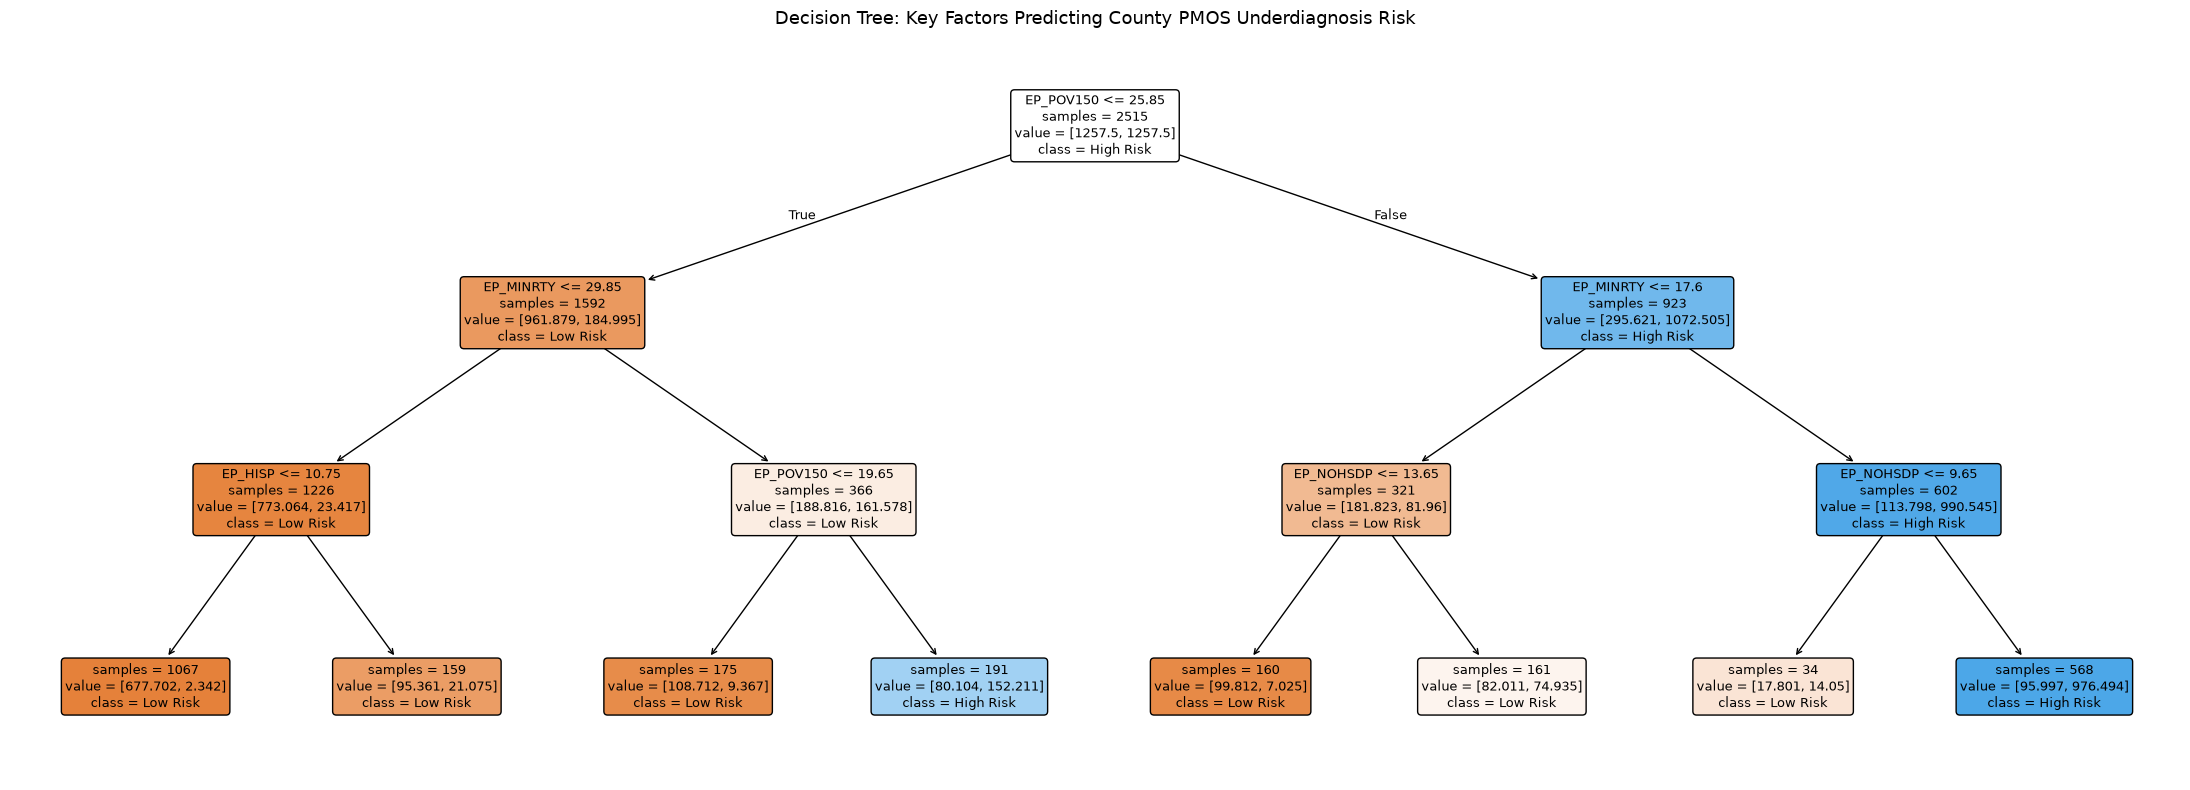

|--- EP_POV150 <= 25.85
|   |--- EP_MINRTY <= 29.85
|   |   |--- EP_HISP <= 10.75
|   |   |   |--- class: 0
|   |   |--- EP_HISP >  10.75
|   |   |   |--- class: 0
|   |--- EP_MINRTY >  29.85
|   |   |--- EP_POV150 <= 19.65
|   |   |   |--- class: 0
|   |   |--- EP_POV150 >  19.65
|   |   |   |--- class: 1
|--- EP_POV150 >  25.85
|   |--- EP_MINRTY <= 17.60
|   |   |--- EP_NOHSDP <= 13.65
|   |   |   |--- class: 0
|   |   |--- EP_NOHSDP >  13.65
|   |   |   |--- class: 0
|   |--- EP_MINRTY >  17.60
|   |   |--- EP_NOHSDP <= 9.65
|   |   |   |--- class: 0
|   |   |--- EP_NOHSDP >  9.65
|   |   |   |--- class: 1



In [67]:
# VISUALIZATION: DECISION TREE - IF/THEN SUMMARY FOR NON-TECHNICAL AUDIENCE
# Shallow tree (depth 3) trained for interpretability, not prediction
# Naturally selects most discriminative features at each split
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
dt.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt,
    feature_names=X.columns.tolist(),
    class_names=["Low Risk", "High Risk"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=False,   # hide Gini — cleaner for non-technical audience
    proportion=False
)
ax.set_title(
    "Decision Tree: Key Factors Predicting County PMOS Underdiagnosis Risk",
    fontsize=13
)
plt.tight_layout()
plt.show()

# Print as text if/then rules for reference
from sklearn.tree import export_text
rules = export_text(dt, feature_names=X.columns.tolist())
print(rules)